In [1]:
import os
import json
from collections import defaultdict
import math
import matplotlib.pyplot as plt
import numpy as np
import math
import torch
import safetensors.torch
import datasets

## Fine-tuning on NQ with reformulated labels?

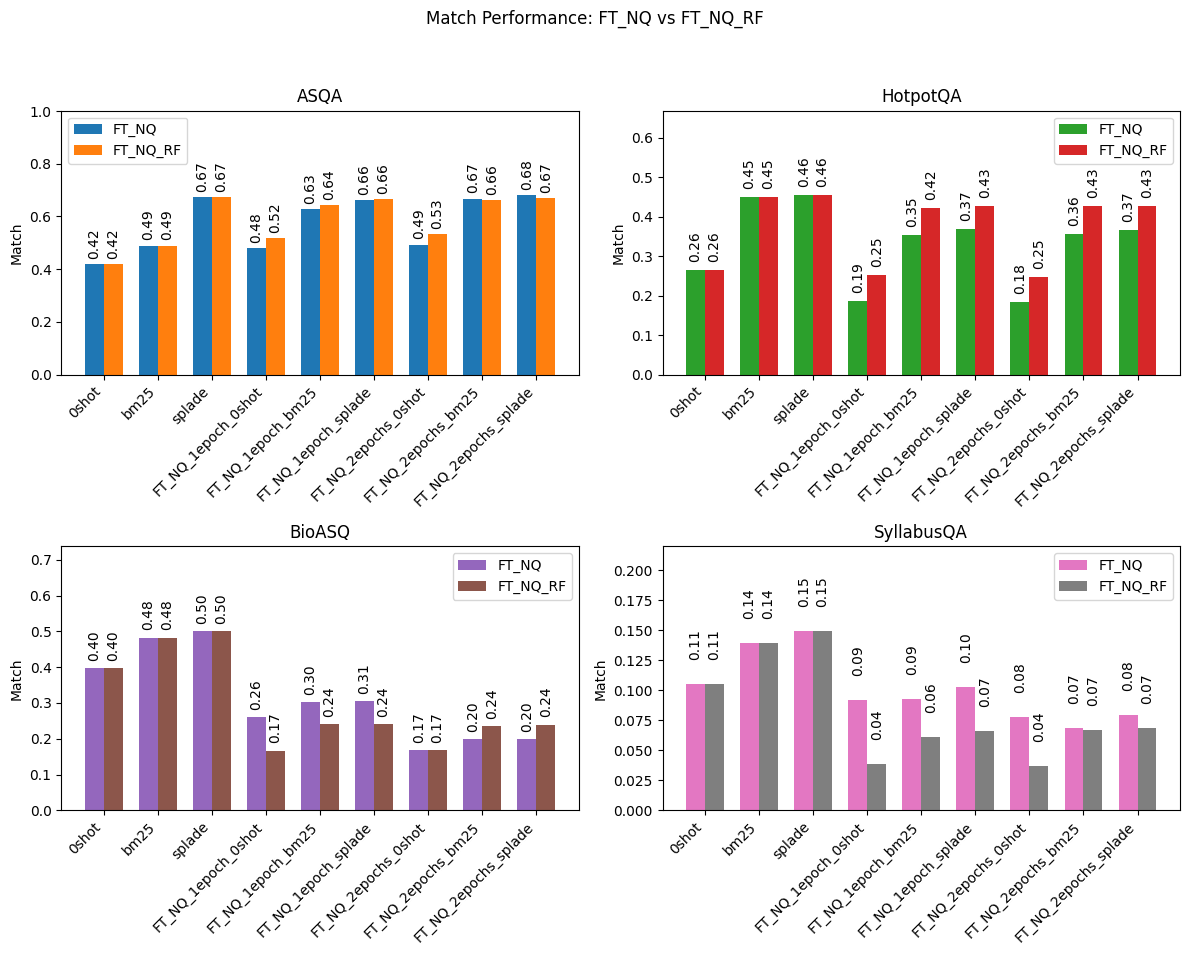

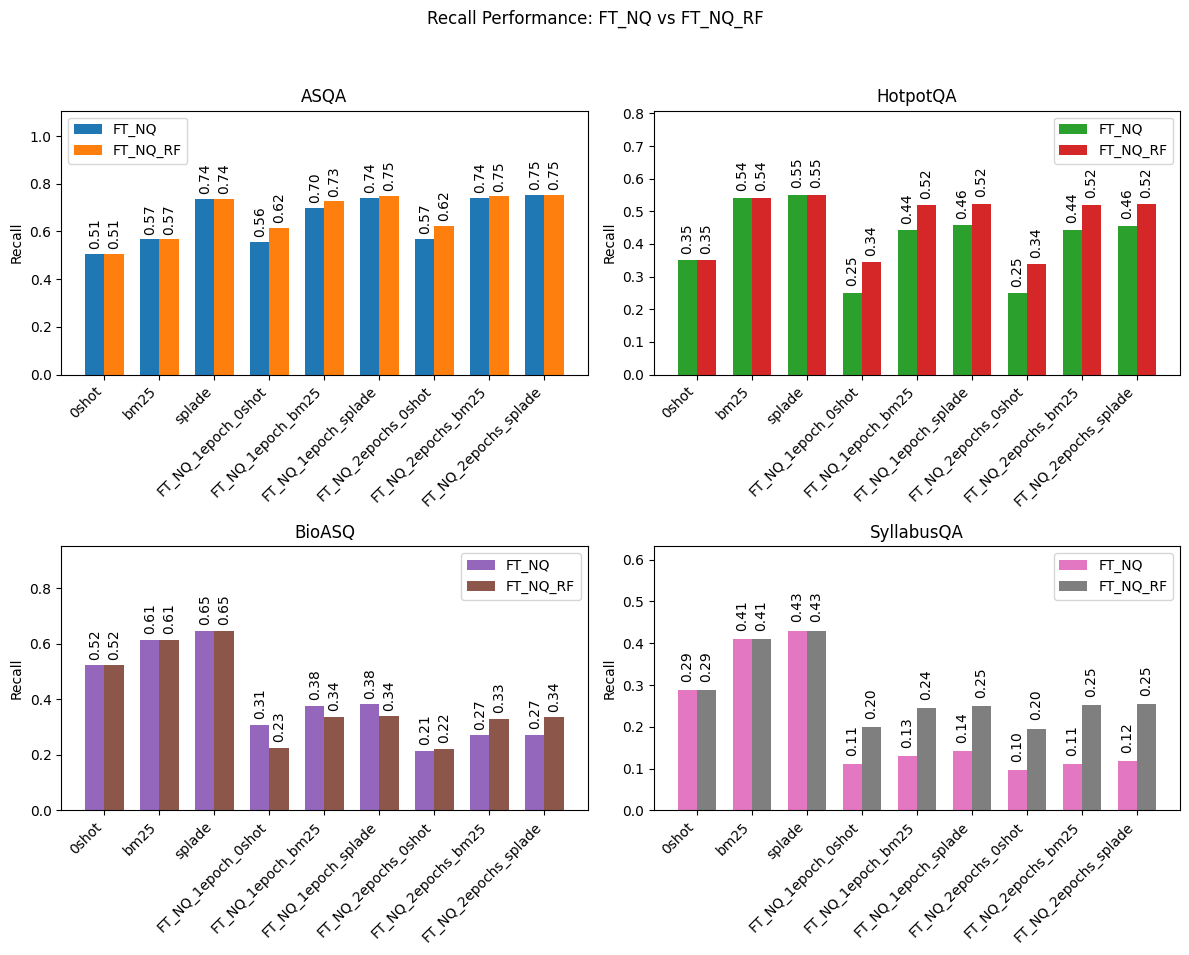

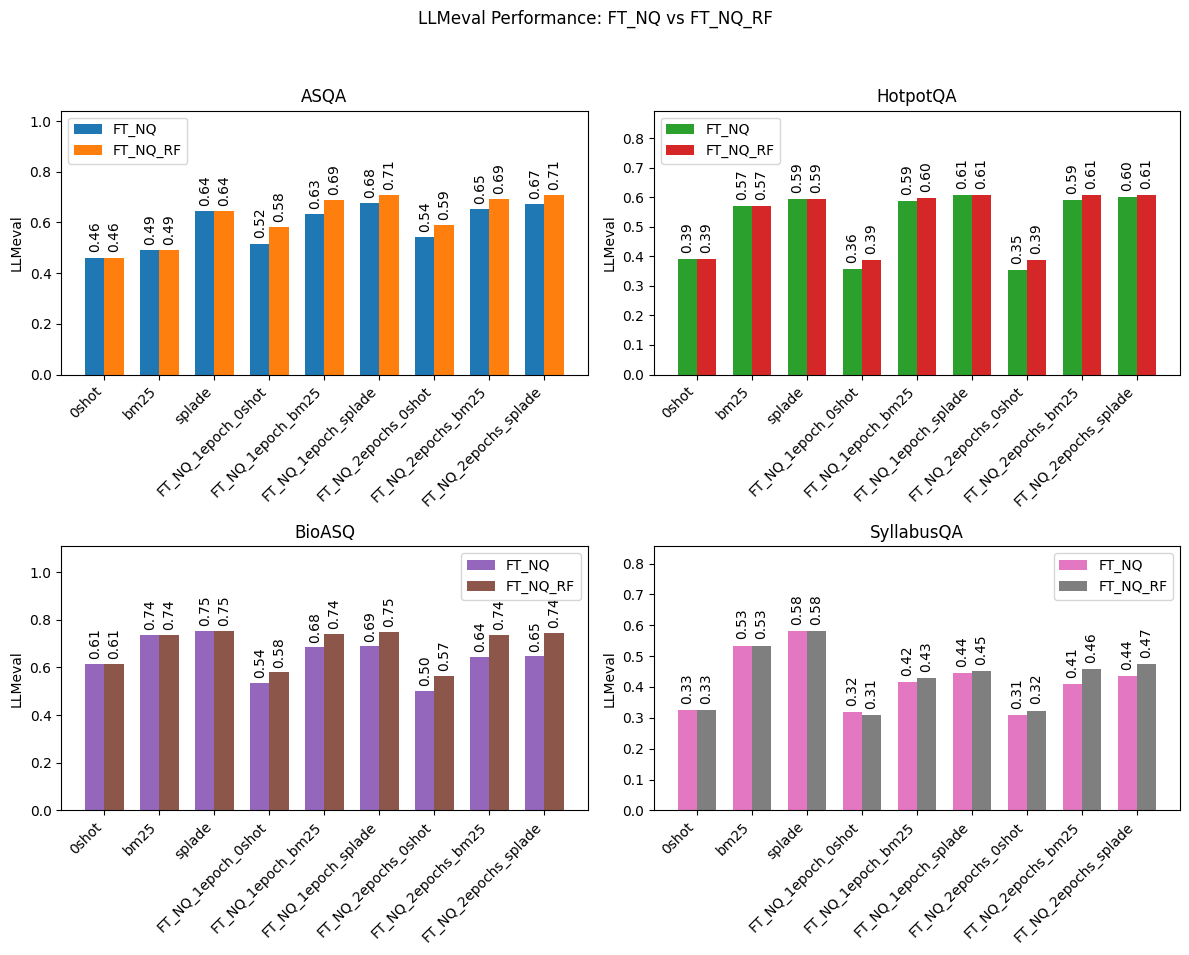

In [3]:
# Define experiment directories for FT_NQ and FT_NQ_RF
FT_NQ_experiments = [
    'll3_8b_0shot', 
    'll3_8b_bm25', 
    'll3_8b_splade',
    'll3_8b_FT_NQ_1epoch_0shot',
    'll3_8b_FT_NQ_1epoch_bm25',
    'll3_8b_FT_NQ_1epoch_splade',
    'll3_8b_FT_NQ_2epochs_0shot',
    'll3_8b_FT_NQ_2epochs_bm25',
    'll3_8b_FT_NQ_2epochs_splade',
]

FT_NQ_RF_labels_experiments = [
    'll3_8b_0shot', 
    'll3_8b_bm25', 
    'll3_8b_splade',
    'll3_8b_FT_NQ_RF_short_1epoch_0shot',
    'll3_8b_FT_NQ_RF_short_1epoch_bm25',
    'll3_8b_FT_NQ_RF_short_1epoch_splade',
    'll3_8b_FT_NQ_RF_short_2epochs_0shot',
    'll3_8b_FT_NQ_RF_short_2epochs_bm25',
    'll3_8b_FT_NQ_RF_short_2epochs_splade',
]

# Root directory where experiment results are stored (4 datasets)
dataset_dirs = [
    'experiments/FT/asqa',
    'experiments/FT/hotpotqa',
    'experiments/FT/bioasq',
    'experiments/FT/syllabusqa'
]

dataset_names = ['ASQA', 'HotpotQA', 'BioASQ', 'SyllabusQA']

# Load metrics for a given experiment directory and dataset
def load_metrics(subdir, dataset_dir):
    metrics_data = {'Match': 0.0, 'Recall': 0.0, 'LLMeval': 0.0}
    json_file_path = os.path.join(dataset_dir, subdir, 'eval_dev_metrics.json')
    if os.path.exists(json_file_path):
        with open(json_file_path, 'r') as json_file:
            metrics = json.load(json_file)
            metrics_data['Match'] = float(metrics.get('M', 0.0))
            metrics_data['Recall'] = float(metrics.get('Recall', 0.0))
            metrics_data['LLMeval'] = float(metrics.get('LLMeval_llama3.1:70b', 0.0))
    return metrics_data

# Plotting function for bar plots with subplots
def plot_metrics_bar_subplots(metric_name, nq_data, nq_rf_data, experiment_labels, title, dataset_names):
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    axs = axs.flatten()

    # Define colors for each dataset pair
    colors = [
        ('#1f77b4', '#ff7f0e'),  # Dataset 1 colors (blue, orange)
        ('#2ca02c', '#d62728'),  # Dataset 2 colors (green, red)
        ('#9467bd', '#8c564b'),  # Dataset 3 colors (purple, brown)
        ('#e377c2', '#7f7f7f'),  # Dataset 4 colors (pink, gray)
    ]

    for i, ax in enumerate(axs):
        bar_width = 0.35
        x = np.arange(len(experiment_labels))
        
        # Plot bars for FT_NQ and FT_NQ_RF for the dataset
        bar1 = ax.bar(x - bar_width/2, nq_data[i], bar_width, label='FT_NQ', color=colors[i][0])
        bar2 = ax.bar(x + bar_width/2, nq_rf_data[i], bar_width, label='FT_NQ_RF', color=colors[i][1])
        
        # Add values on top of bars
        for rect in bar1:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)
        
        for rect in bar2:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)

        # increase y_max to fit vertical numerical values
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        new_y_max = y_max + 0.4 * y_range
        ax.set_ylim([y_min, new_y_max])

        
        # Configure plot for the dataset
        ax.set_title(dataset_names[i])
        ax.set_xticks(x)
        ax.set_xticklabels(experiment_labels, rotation=45, ha="right")
        ax.set_ylabel(metric_name)
        ax.legend()

    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit title
    plt.savefig(f"tmp/figs/{title.replace(' ', '_').replace(':', '_')}.png")
    plt.show()

# Collect data for both NQ and NQ with Reformulated labels per dataset
def collect_experiment_data_per_dataset(experiments, dataset_dirs):
    matches, recalls, llmevals = [], [], []
    for dataset_dir in dataset_dirs:
        dataset_matches, dataset_recalls, dataset_llmevals = [], [], []
        for experiment in experiments:
            metrics = load_metrics(experiment, dataset_dir)
            dataset_matches.append(metrics['Match'])
            dataset_recalls.append(metrics['Recall'])
            dataset_llmevals.append(metrics['LLMeval'])
        matches.append(dataset_matches)
        recalls.append(dataset_recalls)
        llmevals.append(dataset_llmevals)
    return matches, recalls, llmevals

# Collect data for FT_NQ and FT_NQ_RF experiments
nq_matches, nq_recalls, nq_llmevals = collect_experiment_data_per_dataset(FT_NQ_experiments, dataset_dirs)
nq_rf_matches, nq_rf_recalls, nq_rf_llmevals = collect_experiment_data_per_dataset(FT_NQ_RF_labels_experiments, dataset_dirs)

# Define experiment labels (using only the name part after 'll3_8b_')
experiment_labels = [exp[7:] for exp in FT_NQ_experiments]

# Plot the results using bar plots with subplots for 4 datasets
plot_metrics_bar_subplots('Match', nq_matches, nq_rf_matches, experiment_labels, 'Match Performance: FT_NQ vs FT_NQ_RF', dataset_names)
plot_metrics_bar_subplots('Recall', nq_recalls, nq_rf_recalls, experiment_labels, 'Recall Performance: FT_NQ vs FT_NQ_RF', dataset_names)
plot_metrics_bar_subplots('LLMeval', nq_llmevals, nq_rf_llmevals, experiment_labels, 'LLMeval Performance: FT_NQ vs FT_NQ_RF', dataset_names)


## Better fine-tune on NQ or MultiQA ?

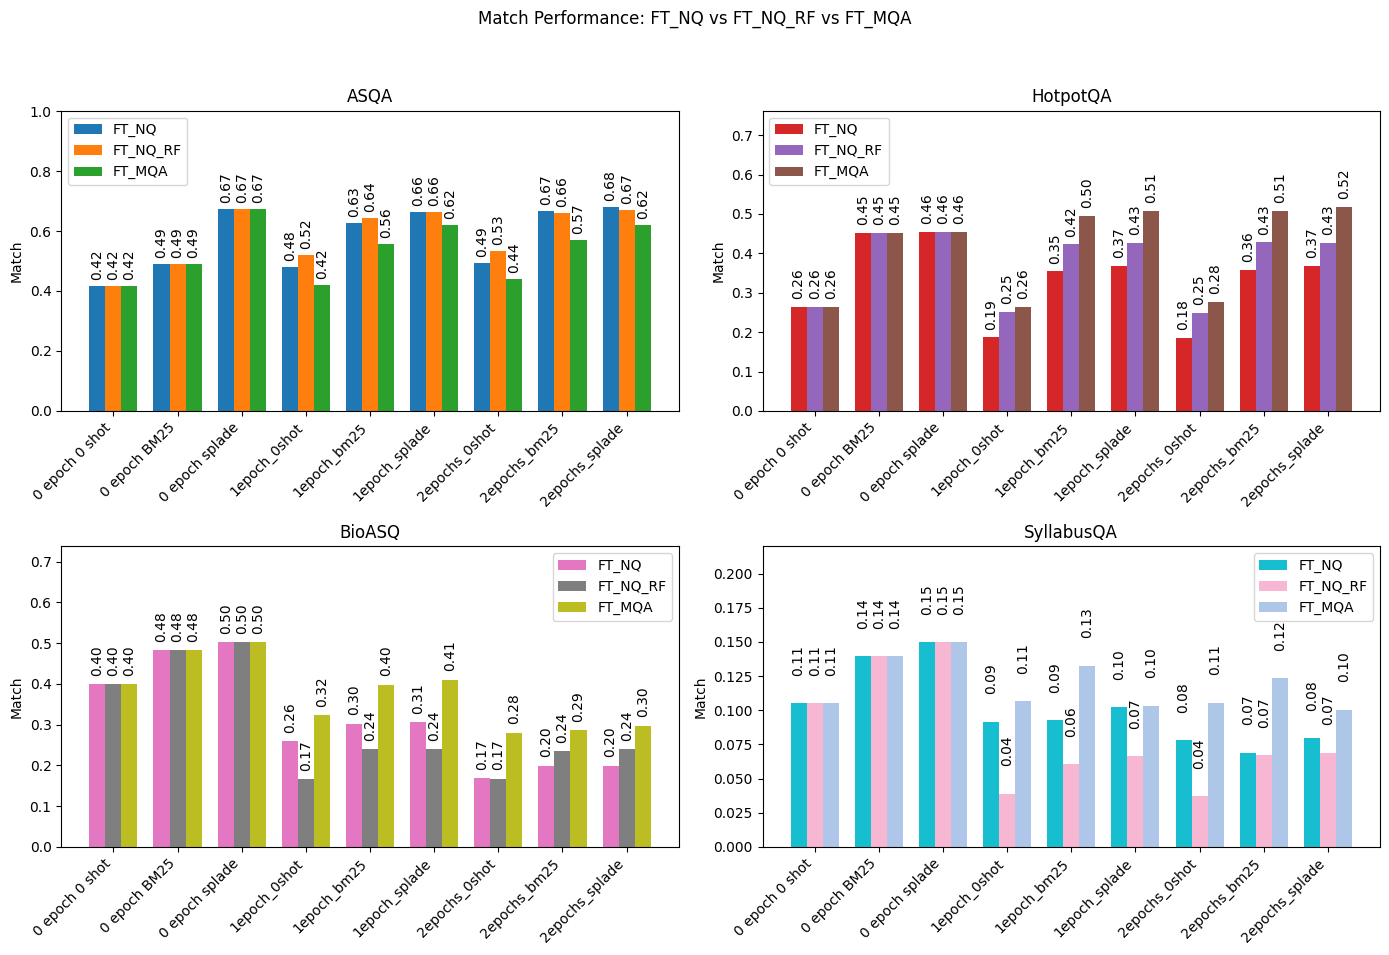

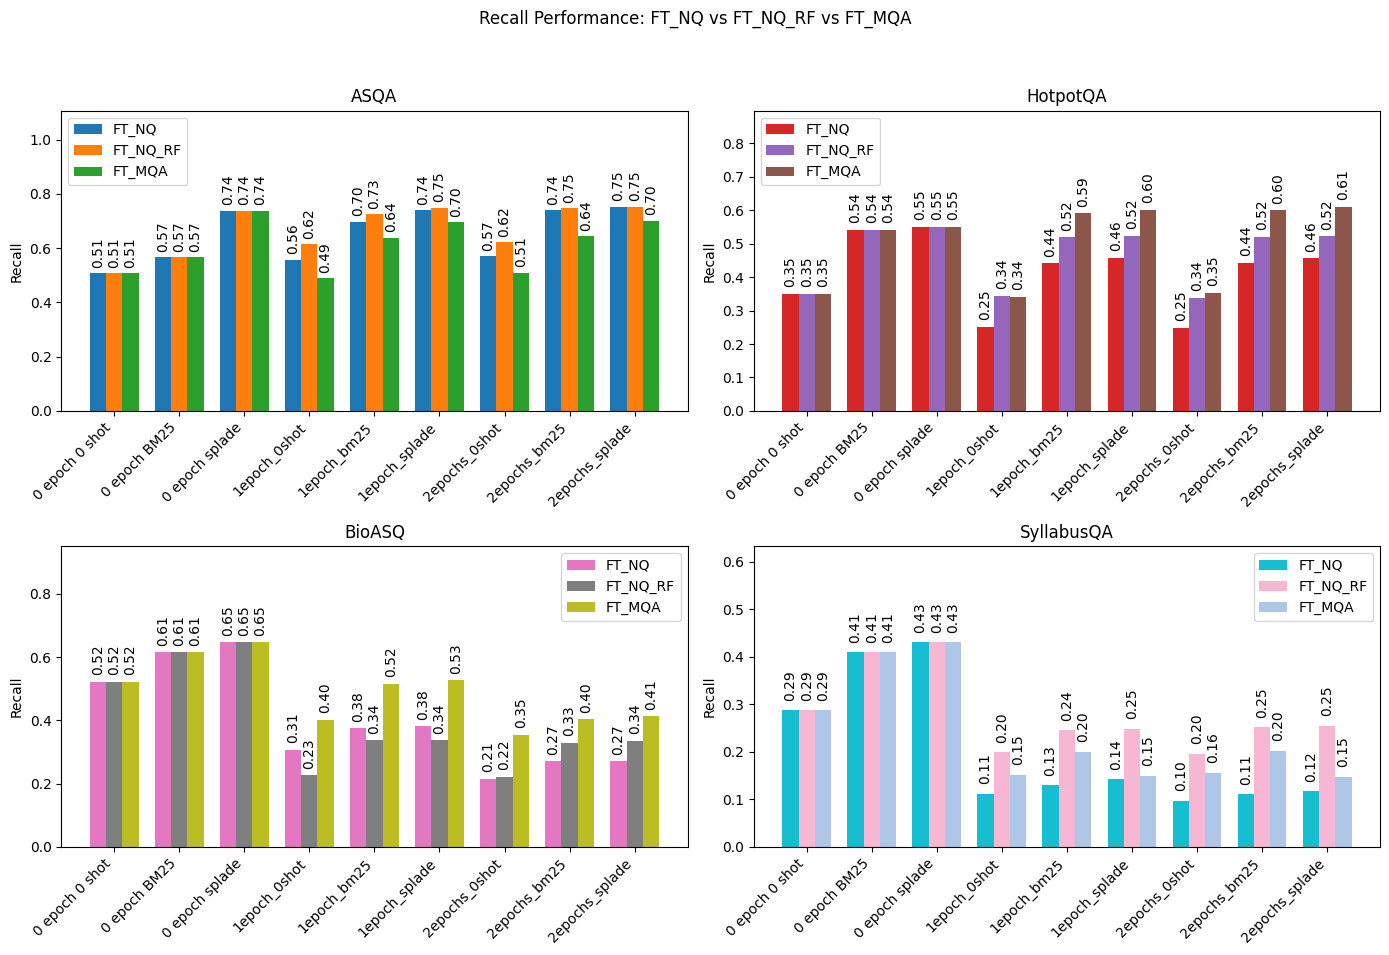

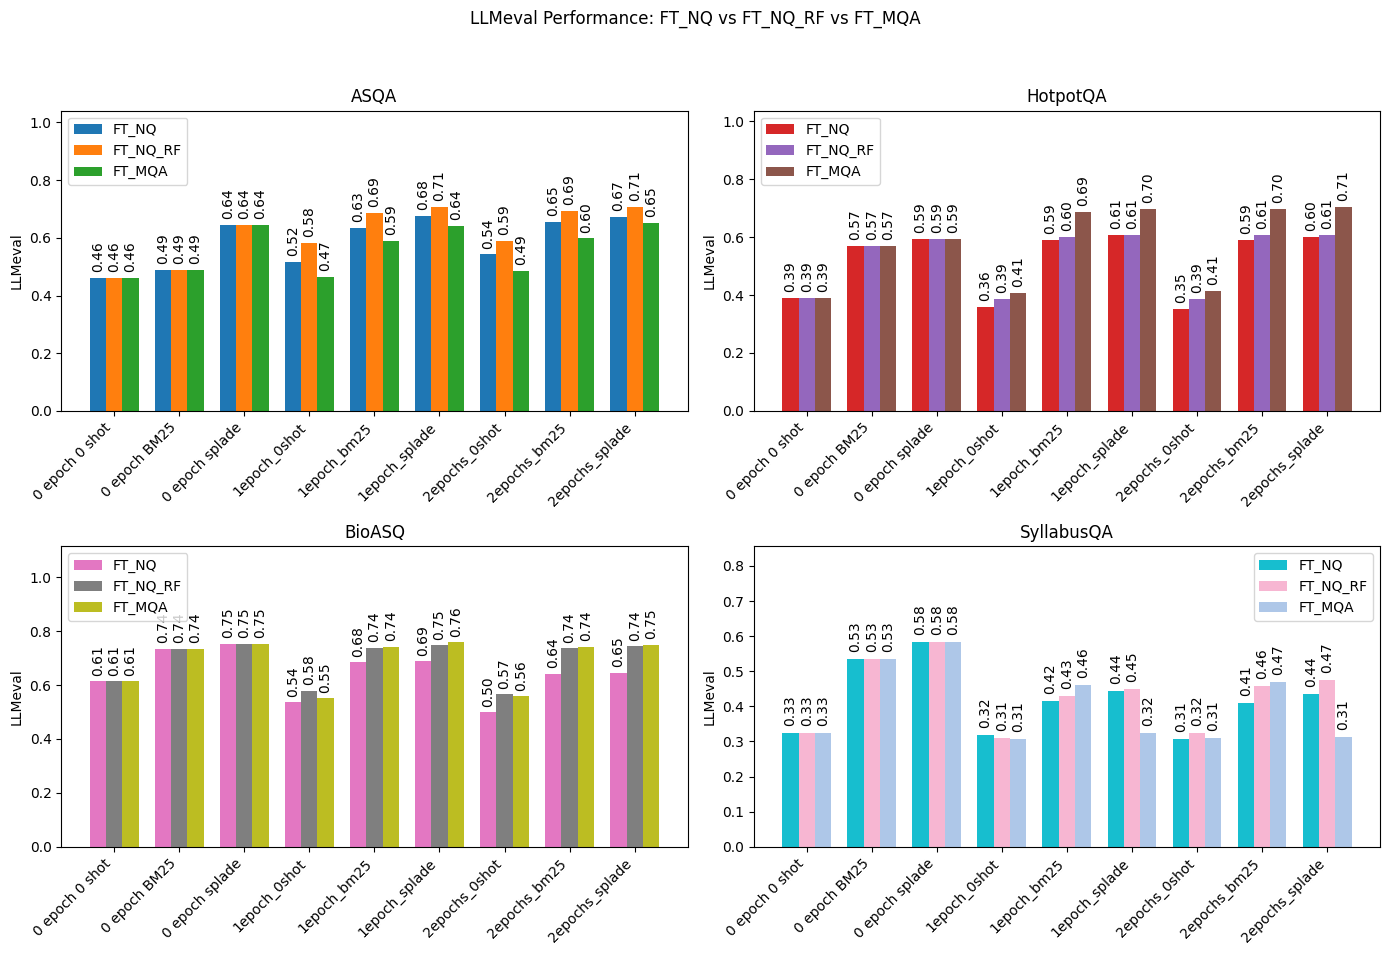

In [5]:
# Experiments lists
FT_NQ_experiments = [
    'll3_8b_0shot', 
    'll3_8b_bm25', 
    'll3_8b_splade',
    'll3_8b_FT_NQ_1epoch_0shot',
    'll3_8b_FT_NQ_1epoch_bm25',
    'll3_8b_FT_NQ_1epoch_splade',
    'll3_8b_FT_NQ_2epochs_0shot',
    'll3_8b_FT_NQ_2epochs_bm25',
    'll3_8b_FT_NQ_2epochs_splade',
]

FT_NQ_RF_labels_experiments = [
    'll3_8b_0shot', 
    'll3_8b_bm25', 
    'll3_8b_splade',
    'll3_8b_FT_NQ_RF_short_1epoch_0shot',
    'll3_8b_FT_NQ_RF_short_1epoch_bm25',
    'll3_8b_FT_NQ_RF_short_1epoch_splade',
    'll3_8b_FT_NQ_RF_short_2epochs_0shot',
    'll3_8b_FT_NQ_RF_short_2epochs_bm25',
    'll3_8b_FT_NQ_RF_short_2epochs_splade',
]

FT_MQA_experiments = [
    'll3_8b_0shot', 
    'll3_8b_bm25', 
    'll3_8b_splade',
    'll3_8b_FT_MQA_BM25_5K_0shot',
    'll3_8b_FT_MQA_BM25_5K_bm25',
    'll3_8b_FT_MQA_BM25_5K_splade',
    'll3_8b_FT_MQA_BM25_11K_0shot',
    'll3_8b_FT_MQA_BM25_11K_bm25',
    'll3_8b_FT_MQA_BM25_11K_splade',
]

# Dataset names
dataset_names = ['ASQA', 'HotpotQA', 'BioASQ', 'SyllabusQA']

# Load metrics function
def load_metrics(subdir, dataset_dir):
    metrics_data = {'Match': 0.0, 'Recall': 0.0, 'LLMeval': 0.0}
    json_file_path = os.path.join(dataset_dir, subdir, 'eval_dev_metrics.json')
    if os.path.exists(json_file_path):
        with open(json_file_path, 'r') as json_file:
            metrics = json.load(json_file)
            metrics_data['Match'] = float(metrics.get('M', 0.0))
            metrics_data['Recall'] = float(metrics.get('Recall', 0.0))
            metrics_data['LLMeval'] = float(metrics.get('LLMeval_llama3.1:70b', 0.0))
    return metrics_data

# Function for collecting data
def collect_experiment_data_per_dataset(experiments, dataset_dirs):
    matches, recalls, llmevals = [], [], []
    for dataset_dir in dataset_dirs:
        dataset_matches, dataset_recalls, dataset_llmevals = [], [], []
        for experiment in experiments:
            metrics = load_metrics(experiment, dataset_dir)
            dataset_matches.append(metrics['Match'])
            dataset_recalls.append(metrics['Recall'])
            dataset_llmevals.append(metrics['LLMeval'])
        matches.append(dataset_matches)
        recalls.append(dataset_recalls)
        llmevals.append(dataset_llmevals)
    return matches, recalls, llmevals

# Collect data for FT_NQ, FT_NQ_RF, and FT_MQA experiments
nq_matches, nq_recalls, nq_llmevals = collect_experiment_data_per_dataset(FT_NQ_experiments, dataset_dirs)
nq_rf_matches, nq_rf_recalls, nq_rf_llmevals = collect_experiment_data_per_dataset(FT_NQ_RF_labels_experiments, dataset_dirs)
mqa_matches, mqa_recalls, mqa_llmevals = collect_experiment_data_per_dataset(FT_MQA_experiments, dataset_dirs)

# Plotting function for bar plots with subplots
def plot_metrics_bar_subplots(metric_name, nq_data, nq_rf_data, mqa_data, experiment_labels, title, dataset_names):
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    axs = axs.flatten()

    # Define colors for each dataset triplet
    colors = [
        ('#1f77b4', '#ff7f0e', '#2ca02c'),  # Dataset 1 colors (blue, orange, green)
        ('#d62728', '#9467bd', '#8c564b'),  # Dataset 2 colors (red, purple, brown)
        ('#e377c2', '#7f7f7f', '#bcbd22'),  # Dataset 3 colors (pink, gray, yellow)
        ('#17becf', '#f7b6d2', '#aec7e8'),  # Dataset 4 colors (cyan, light pink, light blue)
    ]

    for i, ax in enumerate(axs):
        bar_width = 0.25
        x = np.arange(len(experiment_labels))
        
        # Plot bars for FT_NQ, FT_NQ_RF, and FT_MQA for the dataset
        bar1 = ax.bar(x - bar_width, nq_data[i], bar_width, label='FT_NQ', color=colors[i][0])
        bar2 = ax.bar(x, nq_rf_data[i], bar_width, label='FT_NQ_RF', color=colors[i][1])
        bar3 = ax.bar(x + bar_width, mqa_data[i], bar_width, label='FT_MQA', color=colors[i][2])
        
        # Add values on top of bars
        for rect in bar1:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)
        
        for rect in bar2:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)

        for rect in bar3:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)

        # Adjust y-axis limits to fit numerical values
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        new_y_max = y_max + 0.4 * y_range
        ax.set_ylim([y_min, new_y_max])

        # Configure plot for the dataset
        ax.set_title(dataset_names[i])
        ax.set_xticks(x)
        ax.set_xticklabels(experiment_labels, rotation=45, ha="right")
        ax.set_ylabel(metric_name)
        ax.legend()

    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit title
    plt.savefig(f"tmp/figs/{title.replace(' ', '_').replace(':', '_')}.png")
    plt.show()

# Define experiment labels (shortened)
experiment_labels = ["0 epoch 0 shot", "0 epoch BM25", "0 epoch splade"] + [exp[13:] for exp in FT_NQ_experiments[3:]]

# Plot the results using bar plots with subplots for 4 datasets
plot_metrics_bar_subplots('Match', nq_matches, nq_rf_matches, mqa_matches, experiment_labels, 'Match Performance: FT_NQ vs FT_NQ_RF vs FT_MQA', dataset_names)
plot_metrics_bar_subplots('Recall', nq_recalls, nq_rf_recalls, mqa_recalls, experiment_labels, 'Recall Performance: FT_NQ vs FT_NQ_RF vs FT_MQA', dataset_names)
plot_metrics_bar_subplots('LLMeval', nq_llmevals, nq_rf_llmevals, mqa_llmevals, experiment_labels, 'LLMeval Performance: FT_NQ vs FT_NQ_RF vs FT_MQA', dataset_names)


## Fine-tuning with or without distractors?

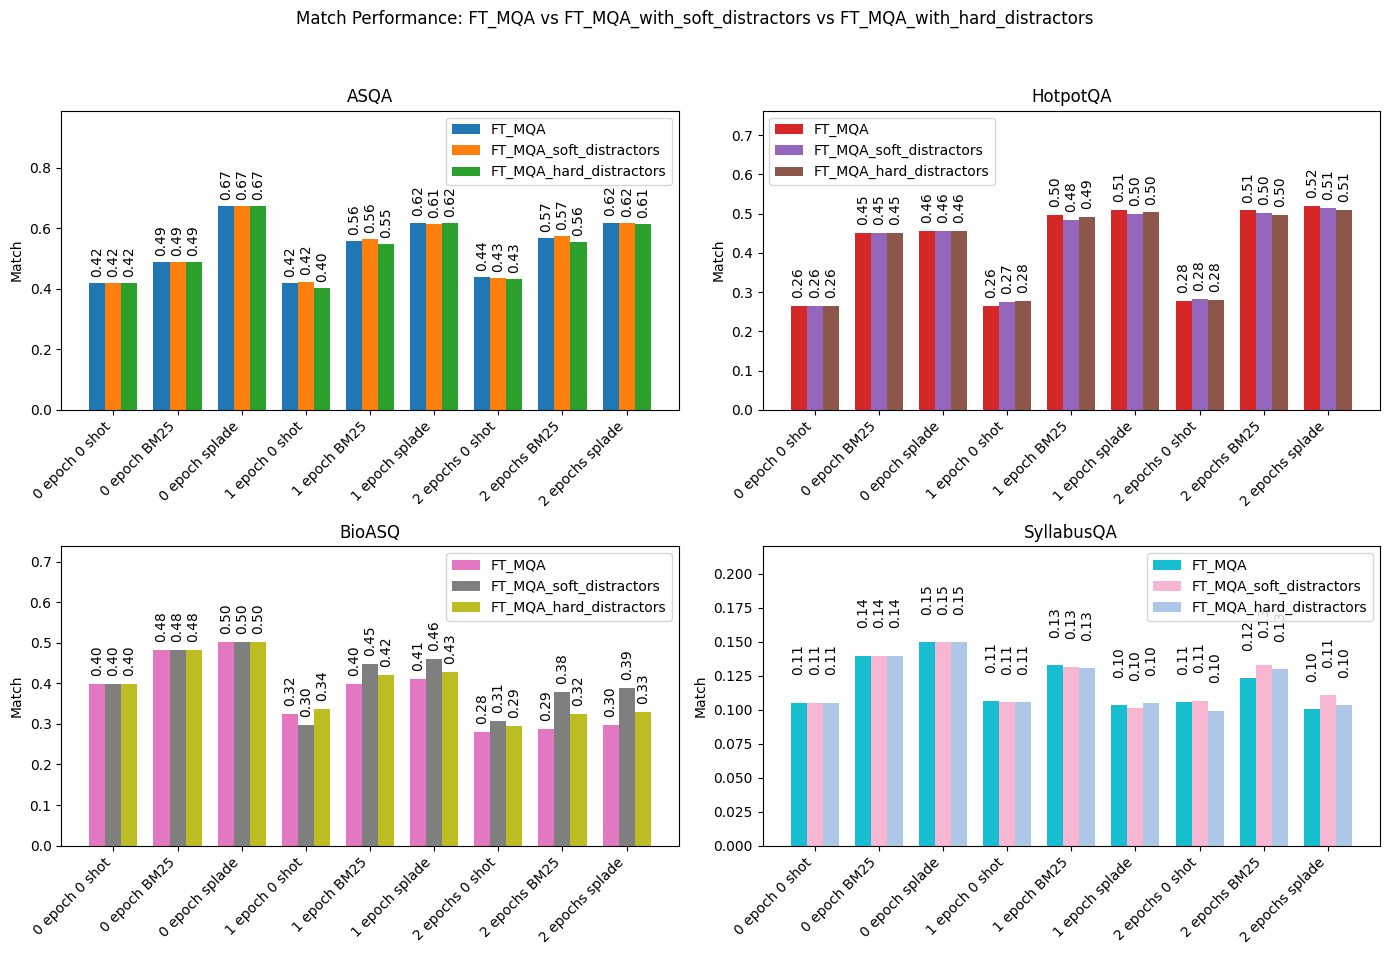

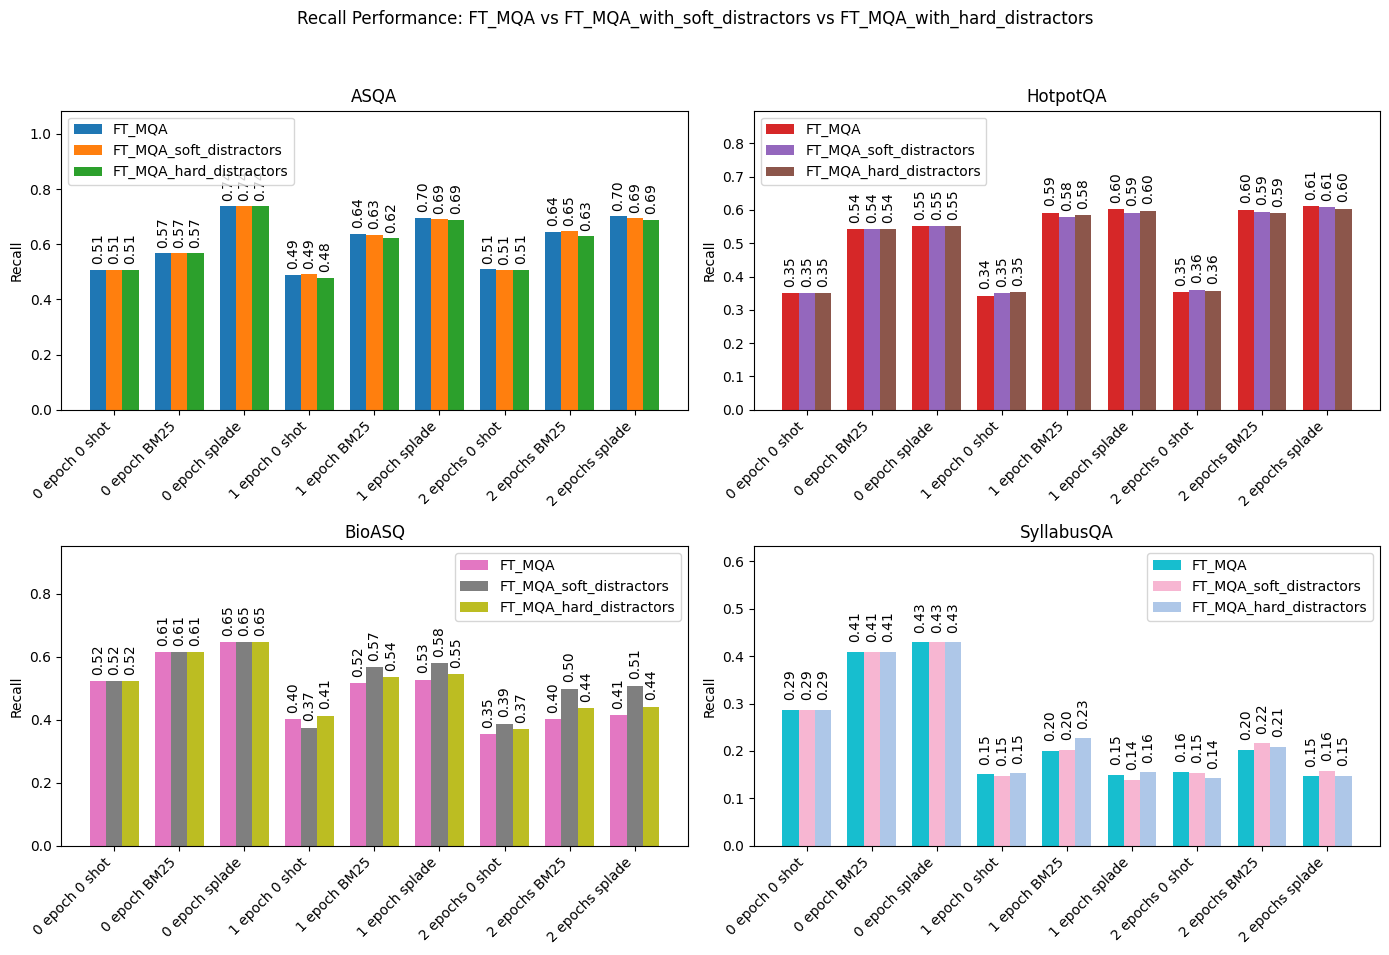

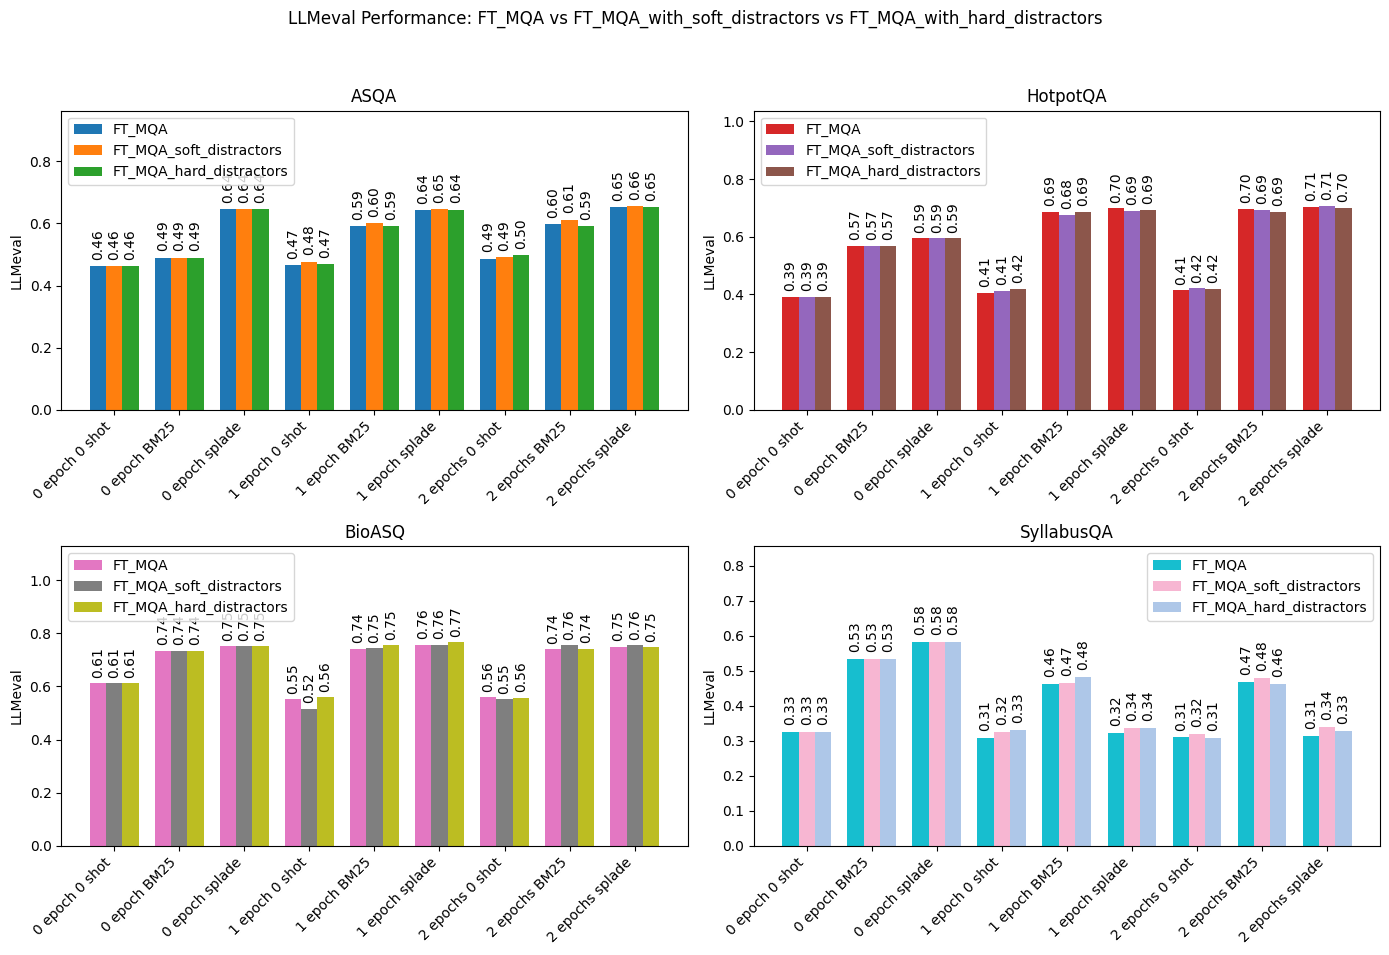

In [6]:
FT_MQA_experiments = [
    'll3_8b_0shot', 
    'll3_8b_bm25', 
    'll3_8b_splade',
    'll3_8b_FT_MQA_BM25_5K_0shot',
    'll3_8b_FT_MQA_BM25_5K_bm25',
    'll3_8b_FT_MQA_BM25_5K_splade',
    'll3_8b_FT_MQA_BM25_11K_0shot',
    'll3_8b_FT_MQA_BM25_11K_bm25',
    'll3_8b_FT_MQA_BM25_11K_splade',
    ]

FT_MQA_with_soft_distractors_experiments = [
    'll3_8b_0shot', 
    'll3_8b_bm25', 
    'll3_8b_splade',
    'll3_8b_FT_MQA_5K_distractors_3_ret_5_P_09_0shot',
    'll3_8b_FT_MQA_5K_distractors_3_ret_5_P_09_bm25',
    'll3_8b_FT_MQA_5K_distractors_3_ret_5_P_09_splade',
    'll3_8b_FT_MQA_11K_distractors_3_ret_5_P_09_0shot',
    'll3_8b_FT_MQA_11K_distractors_3_ret_5_P_09_bm25',
    'll3_8b_FT_MQA_11K_distractors_3_ret_5_P_09_splade',
]

FT_MQA_with_hard_distractors_experiments = [
    'll3_8b_0shot', 
    'll3_8b_bm25', 
    'll3_8b_splade',
    'll3_8b_FT_MQA_5K_distractors_3_ret_5_P_06_0shot',
    'll3_8b_FT_MQA_5K_distractors_3_ret_5_P_06_bm25',
    'll3_8b_FT_MQA_5K_distractors_3_ret_5_P_06_splade',
    'll3_8b_FT_MQA_11K_distractors_3_ret_5_P_06_0shot',
    'll3_8b_FT_MQA_11K_distractors_3_ret_5_P_06_bm25',
    'll3_8b_FT_MQA_11K_distractors_3_ret_5_P_06_splade',
]

# Dataset names
dataset_names = ['ASQA', 'HotpotQA', 'BioASQ', 'SyllabusQA']

# Load metrics function
def load_metrics(subdir, dataset_dir):
    metrics_data = {'Match': 0.0, 'Recall': 0.0, 'LLMeval': 0.0}
    json_file_path = os.path.join(dataset_dir, subdir, 'eval_dev_metrics.json')
    if os.path.exists(json_file_path):
        with open(json_file_path, 'r') as json_file:
            metrics = json.load(json_file)
            metrics_data['Match'] = float(metrics.get('M', 0.0))
            metrics_data['Recall'] = float(metrics.get('Recall', 0.0))
            metrics_data['LLMeval'] = float(metrics.get('LLMeval_llama3.1:70b', 0.0))
    return metrics_data

# Function for collecting data
def collect_experiment_data_per_dataset(experiments, dataset_dirs):
    matches, recalls, llmevals = [], [], []
    for dataset_dir in dataset_dirs:
        dataset_matches, dataset_recalls, dataset_llmevals = [], [], []
        for experiment in experiments:
            metrics = load_metrics(experiment, dataset_dir)
            dataset_matches.append(metrics['Match'])
            dataset_recalls.append(metrics['Recall'])
            dataset_llmevals.append(metrics['LLMeval'])
        matches.append(dataset_matches)
        recalls.append(dataset_recalls)
        llmevals.append(dataset_llmevals)
    return matches, recalls, llmevals

mqa_matches, mqa_recalls, mqa_llmevals = collect_experiment_data_per_dataset(FT_MQA_experiments, dataset_dirs)
mqa_with_soft_distractors_matches, mqa_with_soft_distractors_recalls, mqa_with_soft_distractors_llmevals = collect_experiment_data_per_dataset(FT_MQA_with_soft_distractors_experiments, dataset_dirs)
mqa_with_hard_distractors_matches, mqa_with_hard_distractors_recalls, mqa_with_hard_distractors_llmevals = collect_experiment_data_per_dataset(FT_MQA_with_hard_distractors_experiments, dataset_dirs)

# Plotting function for bar plots with subplots
def plot_metrics_bar_subplots(metric_name, nq_data, nq_rf_data, mqa_data, experiment_labels, title, dataset_names):
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    axs = axs.flatten()

    # Define colors for each dataset triplet
    colors = [
        ('#1f77b4', '#ff7f0e', '#2ca02c'),  # Dataset 1 colors (blue, orange, green)
        ('#d62728', '#9467bd', '#8c564b'),  # Dataset 2 colors (red, purple, brown)
        ('#e377c2', '#7f7f7f', '#bcbd22'),  # Dataset 3 colors (pink, gray, yellow)
        ('#17becf', '#f7b6d2', '#aec7e8'),  # Dataset 4 colors (cyan, light pink, light blue)
    ]

    for i, ax in enumerate(axs):
        bar_width = 0.25
        x = np.arange(len(experiment_labels))
        
        # Plot bars for FT_NQ, FT_NQ_RF, and FT_MQA for the dataset
        bar1 = ax.bar(x - bar_width, nq_data[i], bar_width, label='FT_MQA', color=colors[i][0])
        bar2 = ax.bar(x, nq_rf_data[i], bar_width, label='FT_MQA_soft_distractors', color=colors[i][1])
        bar3 = ax.bar(x + bar_width, mqa_data[i], bar_width, label='FT_MQA_hard_distractors', color=colors[i][2])
        
        # Add values on top of bars
        for rect in bar1:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)
        
        for rect in bar2:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)

        for rect in bar3:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)

        # Adjust y-axis limits to fit numerical values
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        new_y_max = y_max + 0.4 * y_range
        ax.set_ylim([y_min, new_y_max])

        # Configure plot for the dataset
        ax.set_title(dataset_names[i])
        ax.set_xticks(x)
        ax.set_xticklabels(experiment_labels, rotation=45, ha="right")
        ax.set_ylabel(metric_name)
        ax.legend()

    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit title
    plt.savefig(f"tmp/figs/{title.replace(' ', '_').replace(':', '_')}.png")
    plt.show()

# Define experiment labels (shortened)
experiment_labels = ["0 epoch 0 shot", "0 epoch BM25", "0 epoch splade"] +\
      ["1 epoch 0 shot", "1 epoch BM25", "1 epoch splade"] +\
      ["2 epochs 0 shot", "2 epochs BM25", "2 epochs splade"]

# Plot the results using bar plots with subplots for 4 datasets
plot_metrics_bar_subplots('Match', mqa_matches, mqa_with_soft_distractors_matches, mqa_with_hard_distractors_matches, experiment_labels, 'Match Performance: FT_MQA vs FT_MQA_with_soft_distractors vs FT_MQA_with_hard_distractors', dataset_names)
plot_metrics_bar_subplots('Recall', mqa_recalls, mqa_with_soft_distractors_recalls, mqa_with_hard_distractors_recalls, experiment_labels, 'Recall Performance: FT_MQA vs FT_MQA_with_soft_distractors vs FT_MQA_with_hard_distractors', dataset_names)
plot_metrics_bar_subplots('LLMeval', mqa_llmevals, mqa_with_soft_distractors_llmevals, mqa_with_hard_distractors_llmevals, experiment_labels, 'LLMeval Performance: FT_MQA vs FT_MQA_with_soft_distractors vs FT_MQA_with_hard_distractors', dataset_names)


## Fine-tuning on bm25 or on splade?

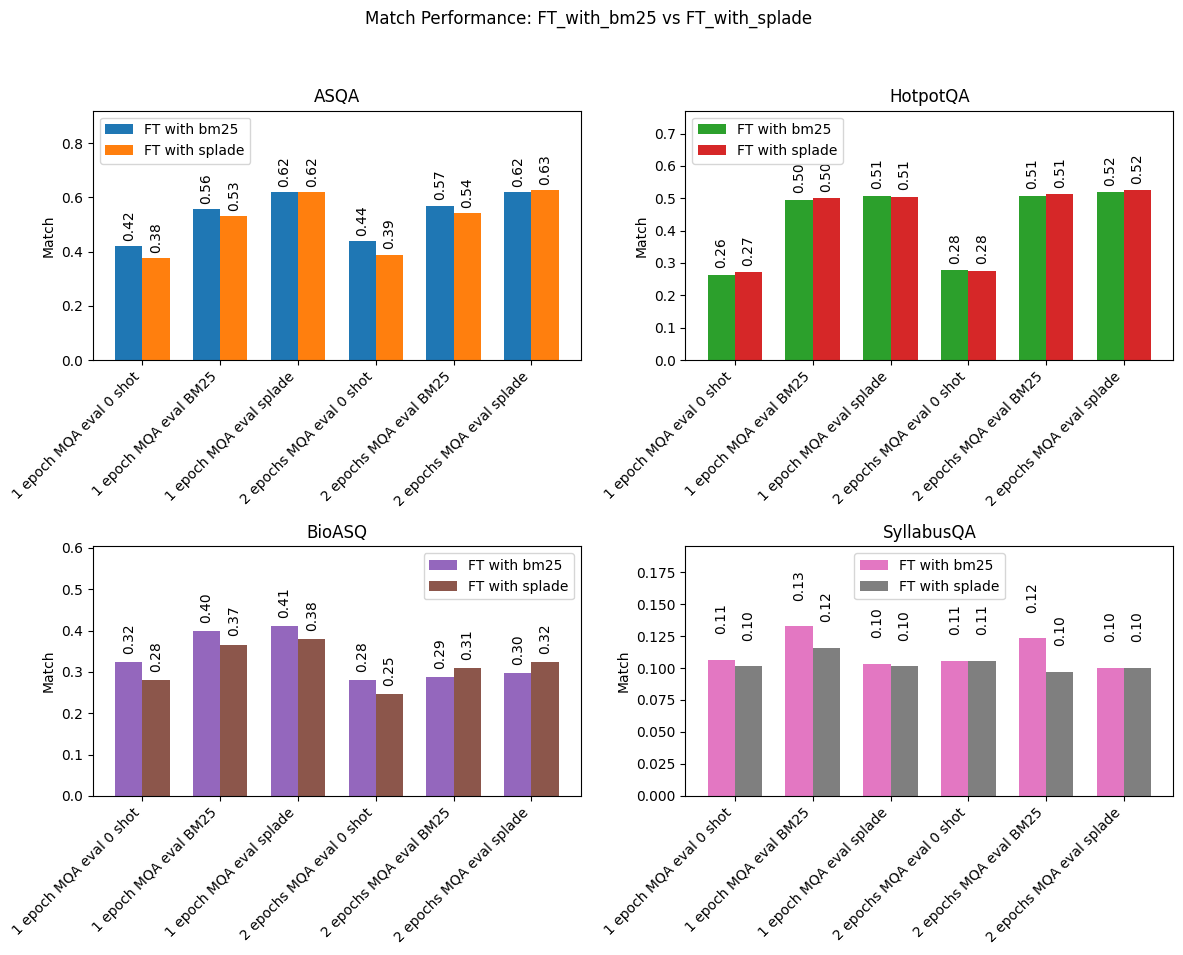

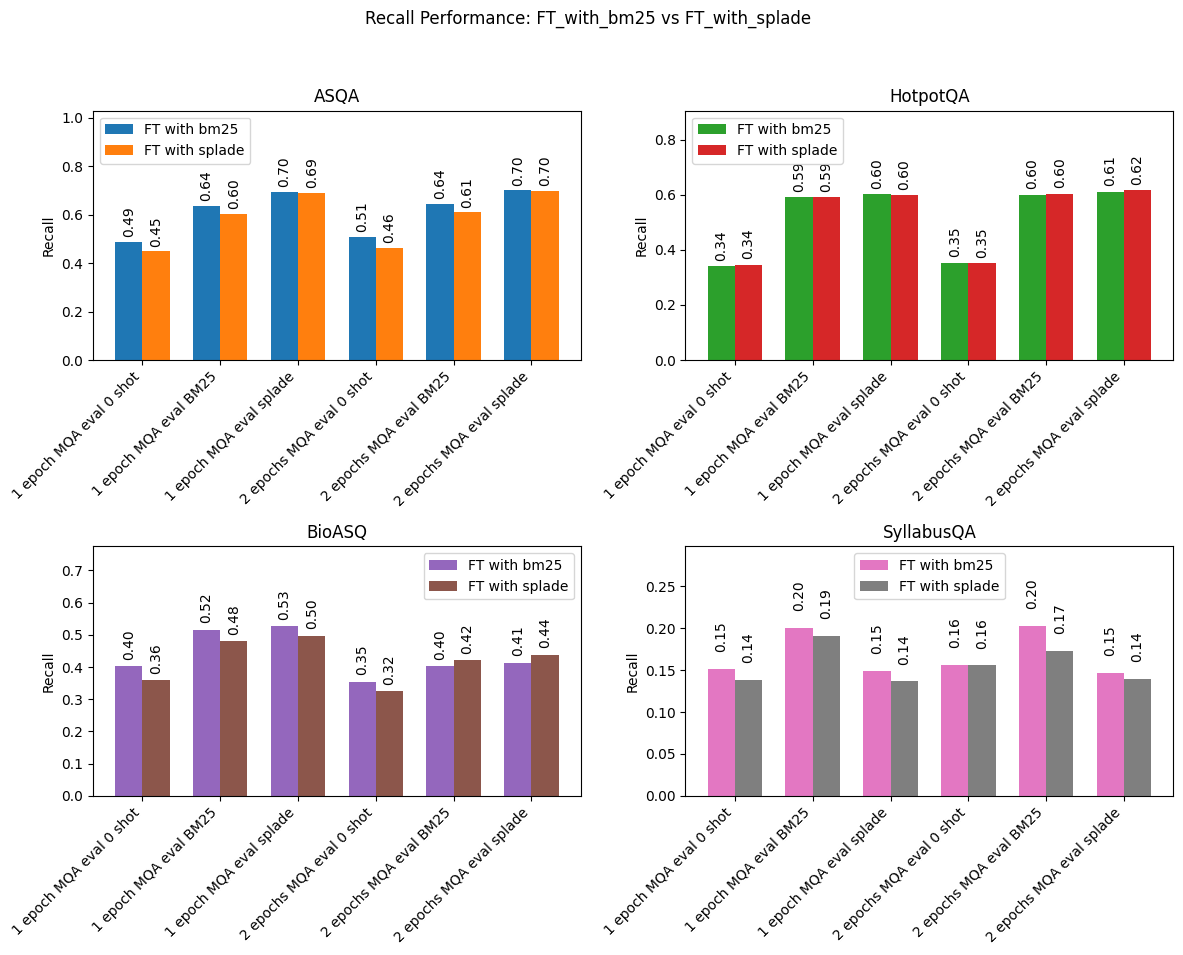

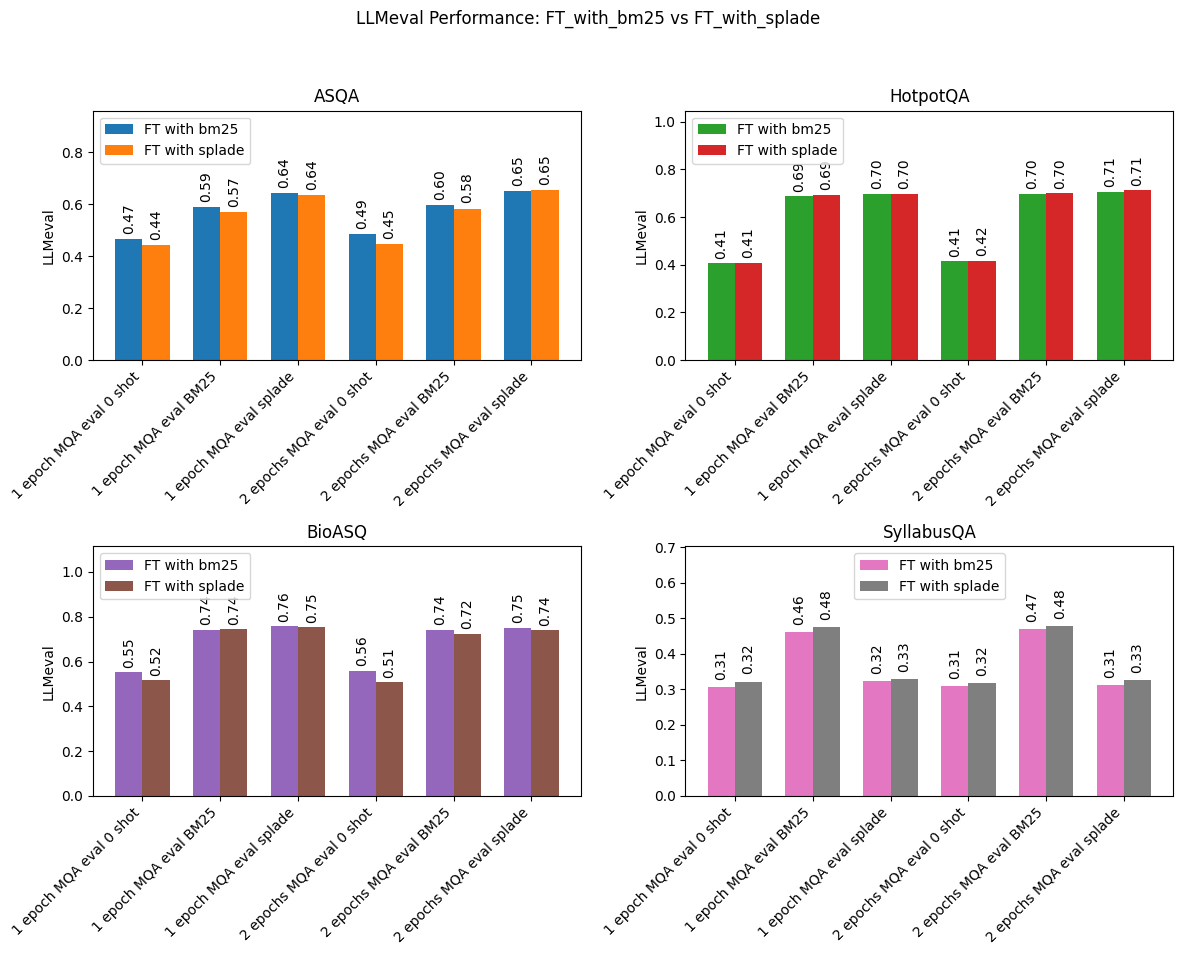

In [3]:
FT_bm25 = [
    'll3_8b_FT_MQA_BM25_5K_0shot',
    'll3_8b_FT_MQA_BM25_5K_bm25',
    'll3_8b_FT_MQA_BM25_5K_splade',
    'll3_8b_FT_MQA_BM25_11K_0shot',
    'll3_8b_FT_MQA_BM25_11K_bm25',
    'll3_8b_FT_MQA_BM25_11K_splade',
    ]

FT_splade = [
    'll3_8b_FT_MQA_splade_5K_0shot',
    'll3_8b_FT_MQA_splade_5K_bm25',
    'll3_8b_FT_MQA_splade_5K_splade',
    'll3_8b_FT_MQA_splade_11K_0shot',
    'll3_8b_FT_MQA_splade_11K_bm25',
    'll3_8b_FT_MQA_splade_11K_splade',
    ]

# Root directory where experiment results are stored (4 datasets)
dataset_dirs = [
    'experiments/FT/asqa',
    'experiments/FT/hotpotqa',
    'experiments/FT/bioasq',
    'experiments/FT/syllabusqa'
]

dataset_names = ['ASQA', 'HotpotQA', 'BioASQ', 'SyllabusQA']

# Load metrics for a given experiment directory and dataset
def load_metrics(subdir, dataset_dir):
    metrics_data = {'Match': 0.0, 'Recall': 0.0, 'LLMeval': 0.0}
    json_file_path = os.path.join(dataset_dir, subdir, 'eval_dev_metrics.json')
    if os.path.exists(json_file_path):
        with open(json_file_path, 'r') as json_file:
            metrics = json.load(json_file)
            metrics_data['Match'] = float(metrics.get('M', 0.0))
            metrics_data['Recall'] = float(metrics.get('Recall', 0.0))
            metrics_data['LLMeval'] = float(metrics.get('LLMeval_llama3.1:70b', 0.0))
    return metrics_data

# Plotting function for bar plots with subplots
def plot_metrics_bar_subplots(metric_name, nq_data, nq_rf_data, experiment_labels, title, dataset_names):
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    axs = axs.flatten()

    # Define colors for each dataset pair
    colors = [
        ('#1f77b4', '#ff7f0e'),  # Dataset 1 colors (blue, orange)
        ('#2ca02c', '#d62728'),  # Dataset 2 colors (green, red)
        ('#9467bd', '#8c564b'),  # Dataset 3 colors (purple, brown)
        ('#e377c2', '#7f7f7f'),  # Dataset 4 colors (pink, gray)
    ]

    for i, ax in enumerate(axs):
        bar_width = 0.35
        x = np.arange(len(experiment_labels))
        
        # Plot bars for FT_NQ and FT_NQ_RF for the dataset
        bar1 = ax.bar(x - bar_width/2, nq_data[i], bar_width, label='FT with bm25', color=colors[i][0])
        bar2 = ax.bar(x + bar_width/2, nq_rf_data[i], bar_width, label='FT with splade', color=colors[i][1])
        
        # Add values on top of bars
        for rect in bar1:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)
        
        for rect in bar2:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)

        # increase y_max to fit vertical numerical values
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        new_y_max = y_max + 0.4 * y_range
        ax.set_ylim([y_min, new_y_max])

        
        # Configure plot for the dataset
        ax.set_title(dataset_names[i])
        ax.set_xticks(x)
        ax.set_xticklabels(experiment_labels, rotation=45, ha="right")
        ax.set_ylabel(metric_name)
        ax.legend()

    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit title
    plt.savefig(f"tmp/figs/{title.replace(' ', '_').replace(':', '_')}.png")
    plt.show()

# Collect data for both NQ and NQ with Reformulated labels per dataset
def collect_experiment_data_per_dataset(experiments, dataset_dirs):
    matches, recalls, llmevals = [], [], []
    for dataset_dir in dataset_dirs:
        dataset_matches, dataset_recalls, dataset_llmevals = [], [], []
        for experiment in experiments:
            metrics = load_metrics(experiment, dataset_dir)
            dataset_matches.append(metrics['Match'])
            dataset_recalls.append(metrics['Recall'])
            dataset_llmevals.append(metrics['LLMeval'])
        matches.append(dataset_matches)
        recalls.append(dataset_recalls)
        llmevals.append(dataset_llmevals)
    return matches, recalls, llmevals

# Collect data for FT_NQ and FT_NQ_RF experiments
FT_bm25_matches, FT_bm25_recalls, FT_bm25_llmevals = collect_experiment_data_per_dataset(FT_bm25, dataset_dirs)
FT_splade_matches, FT_splade_recalls, FT_splade_llmevals = collect_experiment_data_per_dataset(FT_splade, dataset_dirs)

# Define experiment labels (using only the name part after 'll3_8b_')
experiment_labels = ["1 epoch MQA eval 0 shot", "1 epoch MQA eval BM25", "1 epoch MQA eval splade"] +\
      ["2 epochs MQA eval 0 shot", "2 epochs MQA eval BM25", "2 epochs MQA eval splade"]

# Plot the results using bar plots with subplots for 4 datasets
plot_metrics_bar_subplots('Match', FT_bm25_matches, FT_splade_matches, experiment_labels, 'Match Performance: FT_with_bm25 vs FT_with_splade', dataset_names)
plot_metrics_bar_subplots('Recall', FT_bm25_recalls, FT_splade_recalls, experiment_labels, 'Recall Performance: FT_with_bm25 vs FT_with_splade', dataset_names)
plot_metrics_bar_subplots('LLMeval', FT_bm25_llmevals, FT_splade_llmevals, experiment_labels, 'LLMeval Performance: FT_with_bm25 vs FT_with_splade', dataset_names)


## At test-time: 0-shot vs BM25 vs Splade

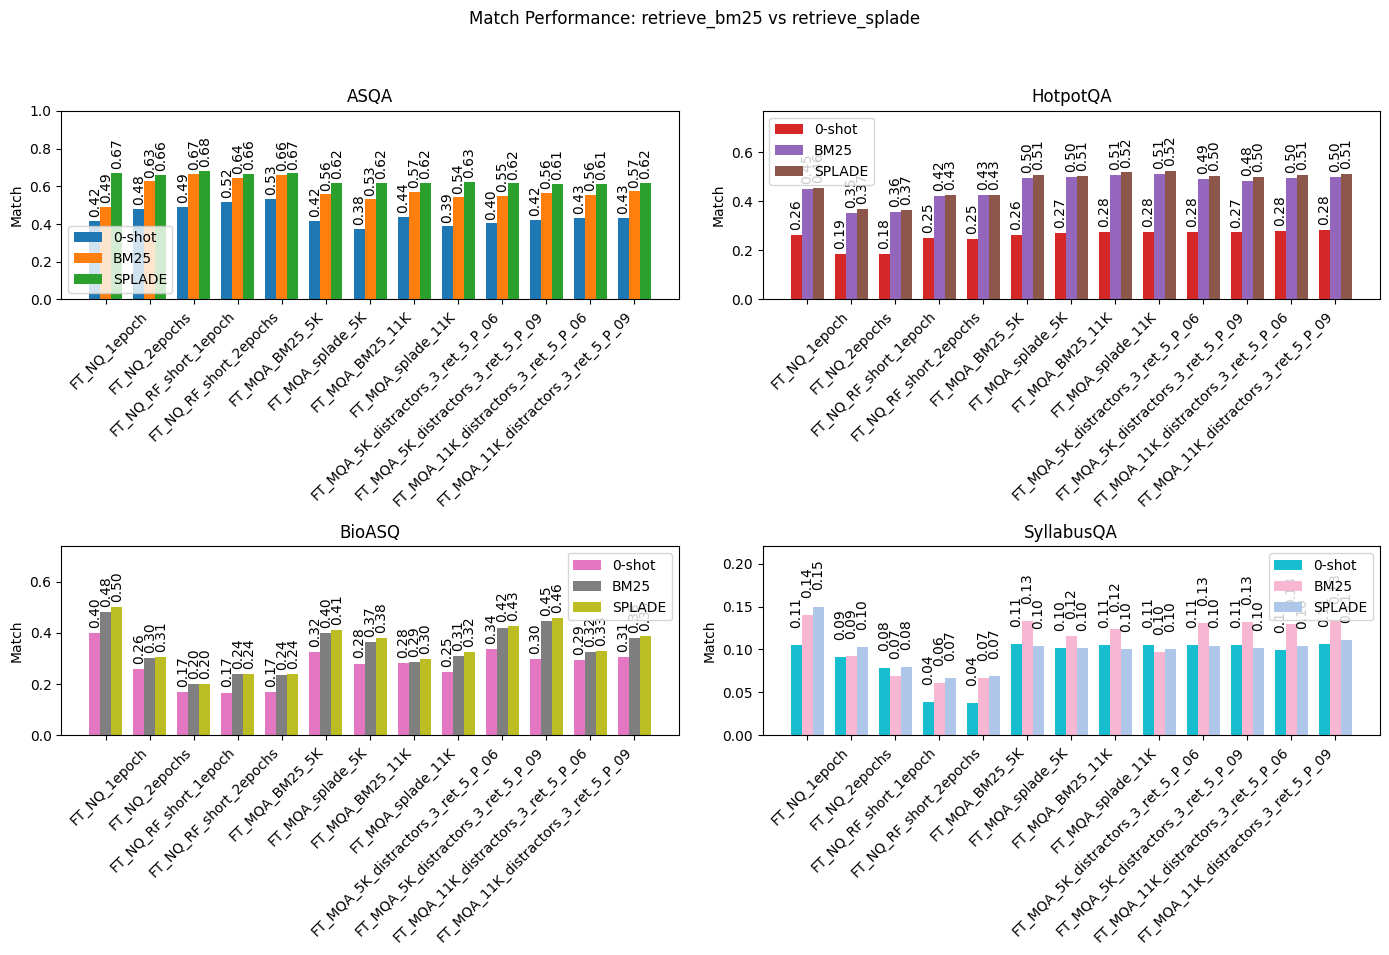

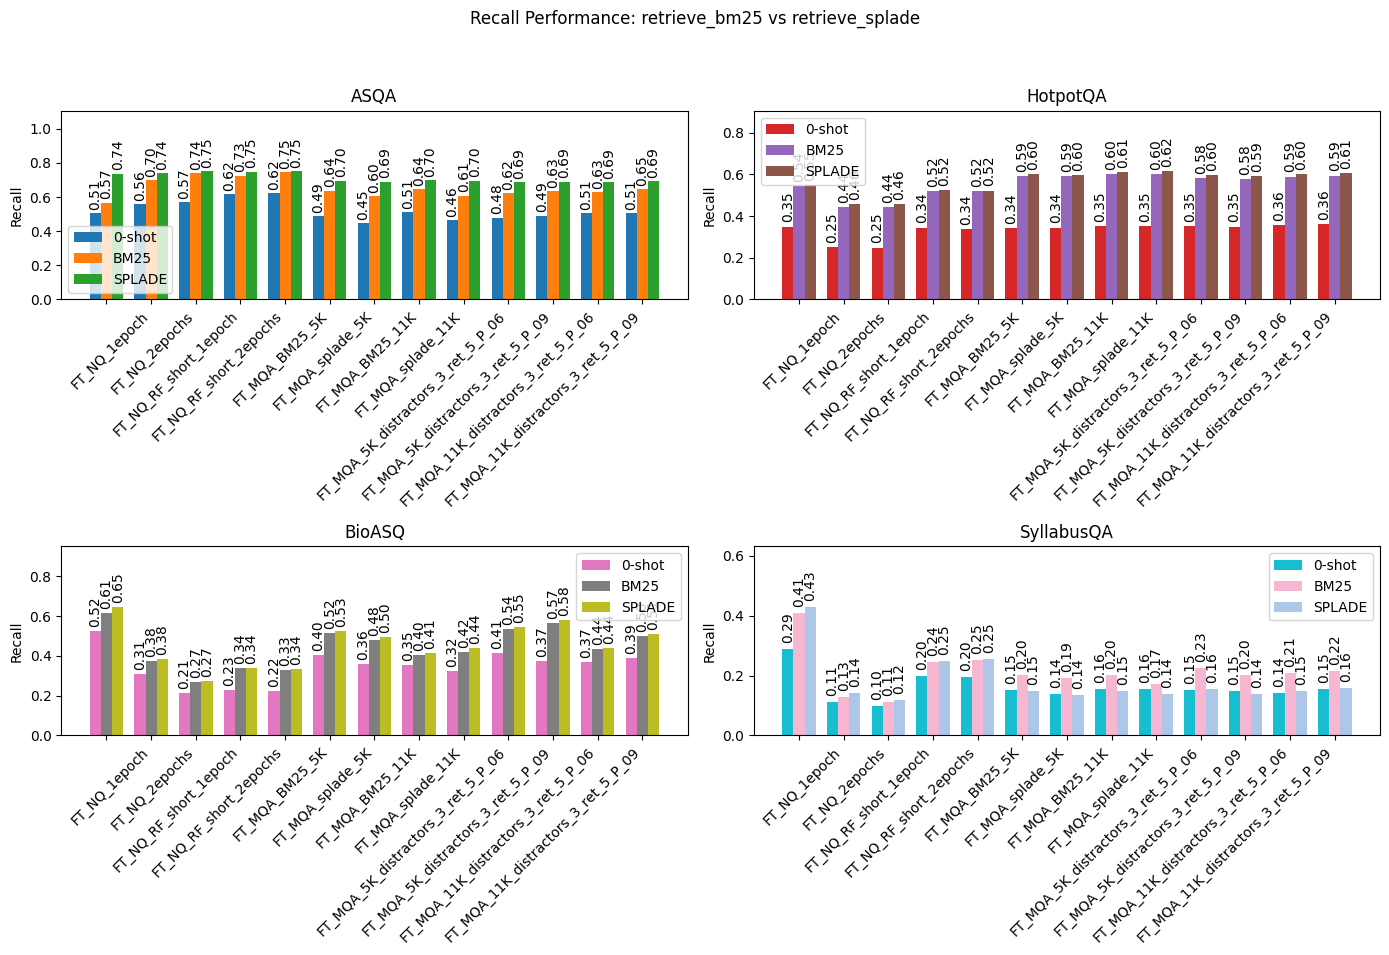

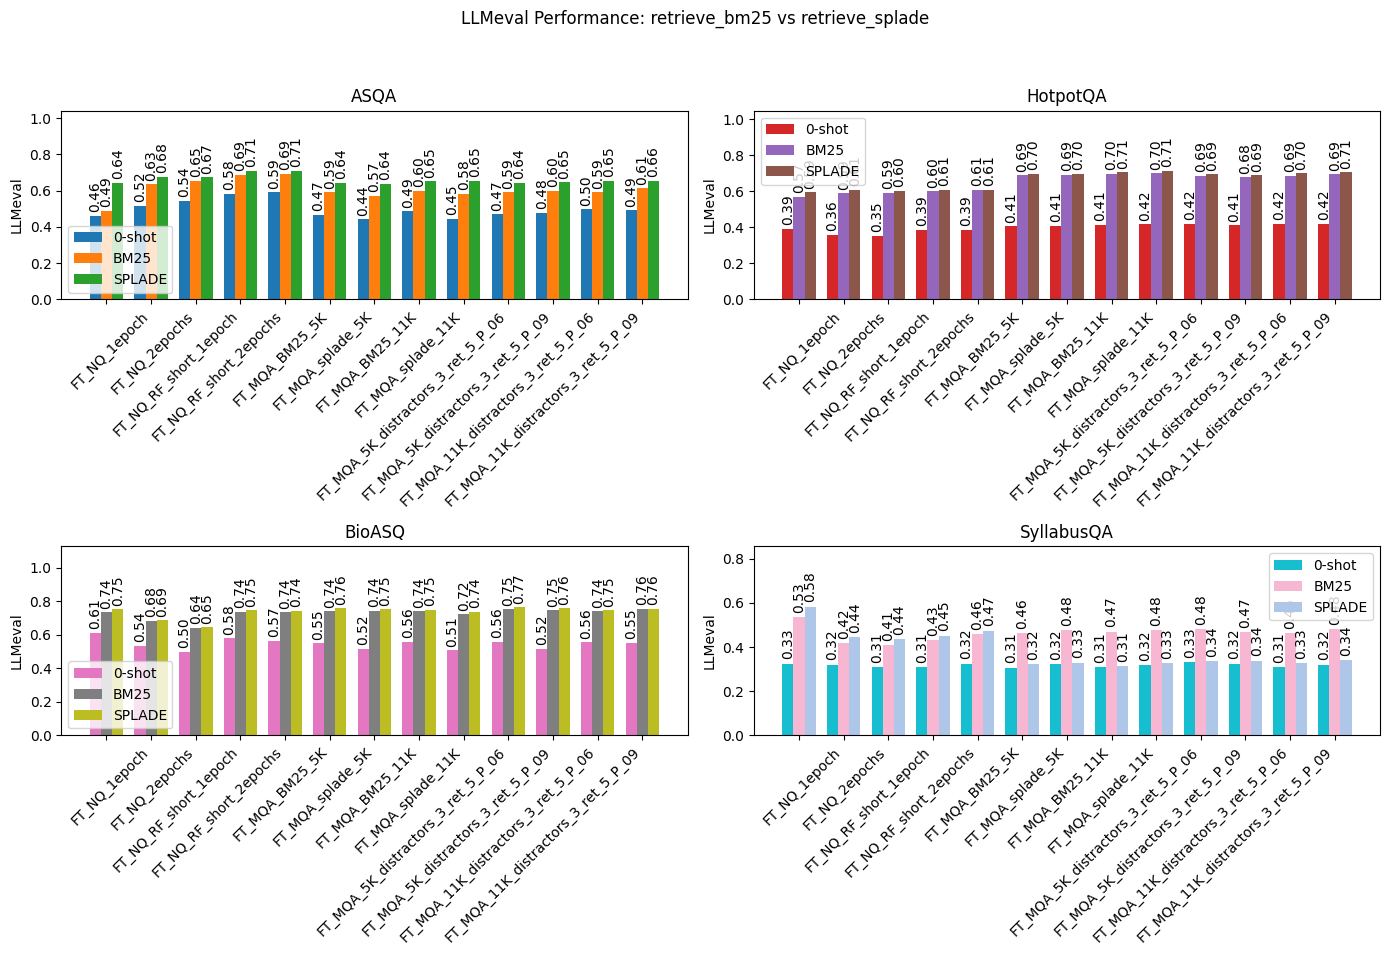

In [9]:
zero_shot_experiments = [
    'll3_8b_0shot',
    'll3_8b_FT_NQ_1epoch_0shot',
    'll3_8b_FT_NQ_2epochs_0shot',
    'll3_8b_FT_NQ_RF_short_1epoch_0shot',
    'll3_8b_FT_NQ_RF_short_2epochs_0shot',
    'll3_8b_FT_MQA_BM25_5K_0shot',
    'll3_8b_FT_MQA_splade_5K_0shot',
    'll3_8b_FT_MQA_BM25_11K_0shot',
    'll3_8b_FT_MQA_splade_11K_0shot',
    'll3_8b_FT_MQA_5K_distractors_3_ret_5_P_06_0shot',
    'll3_8b_FT_MQA_5K_distractors_3_ret_5_P_09_0shot',
    'll3_8b_FT_MQA_11K_distractors_3_ret_5_P_06_0shot',
    'll3_8b_FT_MQA_11K_distractors_3_ret_5_P_09_0shot',
]

bm25_retrieval_experiments = [
    'll3_8b_bm25',
    'll3_8b_FT_NQ_1epoch_bm25',
    'll3_8b_FT_NQ_2epochs_bm25',
    'll3_8b_FT_NQ_RF_short_1epoch_bm25',
    'll3_8b_FT_NQ_RF_short_2epochs_bm25',
    'll3_8b_FT_MQA_BM25_5K_bm25',
    'll3_8b_FT_MQA_splade_5K_bm25',
    'll3_8b_FT_MQA_BM25_11K_bm25',
    'll3_8b_FT_MQA_splade_11K_bm25',
    'll3_8b_FT_MQA_5K_distractors_3_ret_5_P_06_bm25',
    'll3_8b_FT_MQA_5K_distractors_3_ret_5_P_09_bm25',
    'll3_8b_FT_MQA_11K_distractors_3_ret_5_P_06_bm25',
    'll3_8b_FT_MQA_11K_distractors_3_ret_5_P_09_bm25',
]

splade_retrieval_experiments = [
    'll3_8b_splade',
    'll3_8b_FT_NQ_1epoch_splade',
    'll3_8b_FT_NQ_2epochs_splade',
    'll3_8b_FT_NQ_RF_short_1epoch_splade',
    'll3_8b_FT_NQ_RF_short_2epochs_splade',
    'll3_8b_FT_MQA_BM25_5K_splade',
    'll3_8b_FT_MQA_splade_5K_splade',
    'll3_8b_FT_MQA_BM25_11K_splade',
    'll3_8b_FT_MQA_splade_11K_splade',
    'll3_8b_FT_MQA_5K_distractors_3_ret_5_P_06_splade',
    'll3_8b_FT_MQA_5K_distractors_3_ret_5_P_09_splade',
    'll3_8b_FT_MQA_11K_distractors_3_ret_5_P_06_splade',
    'll3_8b_FT_MQA_11K_distractors_3_ret_5_P_09_splade',
]


# Dataset names
dataset_names = ['ASQA', 'HotpotQA', 'BioASQ', 'SyllabusQA']

# Load metrics function
def load_metrics(subdir, dataset_dir):
    metrics_data = {'Match': 0.0, 'Recall': 0.0, 'LLMeval': 0.0}
    json_file_path = os.path.join(dataset_dir, subdir, 'eval_dev_metrics.json')
    if os.path.exists(json_file_path):
        with open(json_file_path, 'r') as json_file:
            metrics = json.load(json_file)
            metrics_data['Match'] = float(metrics.get('M', 0.0))
            metrics_data['Recall'] = float(metrics.get('Recall', 0.0))
            metrics_data['LLMeval'] = float(metrics.get('LLMeval_llama3.1:70b', 0.0))
    return metrics_data

# Function for collecting data
def collect_experiment_data_per_dataset(experiments, dataset_dirs):
    matches, recalls, llmevals = [], [], []
    for dataset_dir in dataset_dirs:
        dataset_matches, dataset_recalls, dataset_llmevals = [], [], []
        for experiment in experiments:
            metrics = load_metrics(experiment, dataset_dir)
            dataset_matches.append(metrics['Match'])
            dataset_recalls.append(metrics['Recall'])
            dataset_llmevals.append(metrics['LLMeval'])
        matches.append(dataset_matches)
        recalls.append(dataset_recalls)
        llmevals.append(dataset_llmevals)
    return matches, recalls, llmevals

# Collect data for 0-shot, BM25, and SPLADE experiments
zero_shot_matches, zero_shot_recalls, zero_shot_llmevals = collect_experiment_data_per_dataset(zero_shot_experiments, dataset_dirs)
bm25_matches, bm25_recalls, bm25_llmevals = collect_experiment_data_per_dataset(bm25_retrieval_experiments, dataset_dirs)
splade_matches, splade_recalls, splade_llmevals = collect_experiment_data_per_dataset(splade_retrieval_experiments, dataset_dirs)

# Plotting function for bar plots with subplots
def plot_metrics_bar_subplots(metric_name, zero_shot_data, bm25_data, splade_data, experiment_labels, title, dataset_names):
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    axs = axs.flatten()

    # Define colors for each dataset triplet
    colors = [
        ('#1f77b4', '#ff7f0e', '#2ca02c'),  # Dataset 1 colors (blue, orange, green)
        ('#d62728', '#9467bd', '#8c564b'),  # Dataset 2 colors (red, purple, brown)
        ('#e377c2', '#7f7f7f', '#bcbd22'),  # Dataset 3 colors (pink, gray, yellow)
        ('#17becf', '#f7b6d2', '#aec7e8'),  # Dataset 4 colors (cyan, light pink, light blue)
    ]

    for i, ax in enumerate(axs):
        bar_width = 0.25
        x = np.arange(len(experiment_labels))
        
        # Plot bars for 0-shot, BM25, and SPLADE for the dataset
        bar1 = ax.bar(x - bar_width, zero_shot_data[i], bar_width, label='0-shot', color=colors[i][0])
        bar2 = ax.bar(x, bm25_data[i], bar_width, label='BM25', color=colors[i][1])
        bar3 = ax.bar(x + bar_width, splade_data[i], bar_width, label='SPLADE', color=colors[i][2])
        
        # Add values on top of bars
        for rect in bar1:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)
        
        for rect in bar2:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)

        for rect in bar3:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)

        # Adjust y-axis limits to fit numerical values
        y_min, y_max = ax.get_ylim()
        y_range = y_max - y_min
        new_y_max = y_max + 0.4 * y_range
        ax.set_ylim([y_min, new_y_max])

        
        # Configure plot for the dataset
        ax.set_title(dataset_names[i])
        ax.set_xticks(x)
        ax.set_xticklabels(experiment_labels, rotation=45, ha="right")
        ax.set_ylabel(metric_name)
        ax.legend()

    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit title
    plt.savefig(f"tmp/figs/{title.replace(' ', '_').replace(':', '_')}.png")
    plt.show()


# Define experiment labels (using only the name part after 'll3_8b_')
experiment_labels = [exp[7:-7] for exp in splade_retrieval_experiments]

# Plot the results using bar plots with subplots for 4 datasets
plot_metrics_bar_subplots('Match', zero_shot_matches, bm25_matches, splade_matches, experiment_labels, 'Match Performance: retrieve_bm25 vs retrieve_splade', dataset_names)
plot_metrics_bar_subplots('Recall', zero_shot_recalls, bm25_recalls, splade_recalls, experiment_labels, 'Recall Performance: retrieve_bm25 vs retrieve_splade', dataset_names)
plot_metrics_bar_subplots('LLMeval', zero_shot_llmevals, bm25_llmevals, splade_llmevals, experiment_labels, 'LLMeval Performance: retrieve_bm25 vs retrieve_splade', dataset_names)

# Distillation

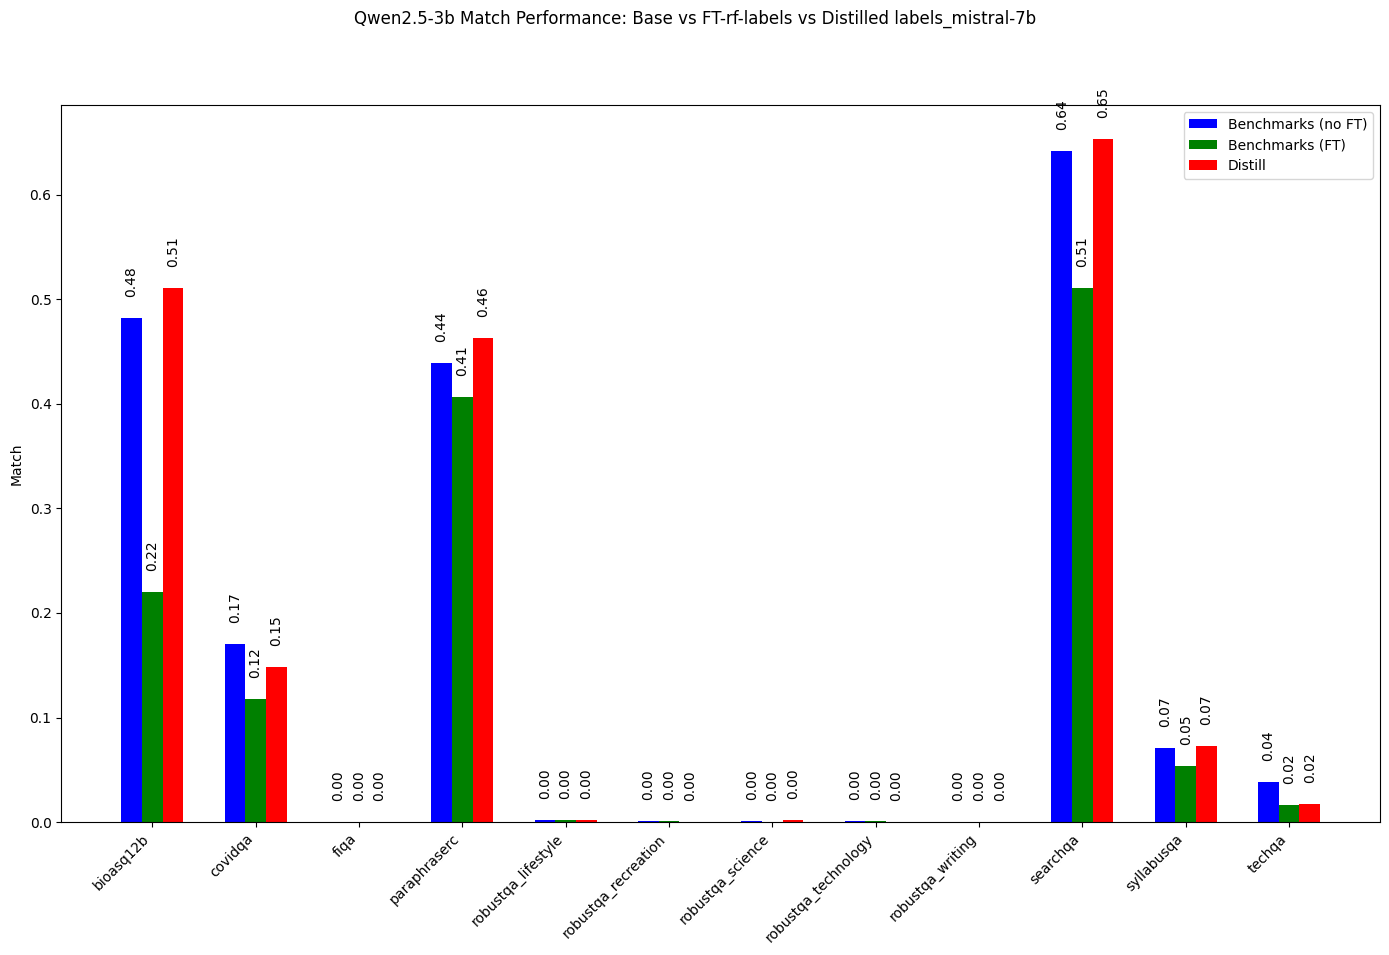

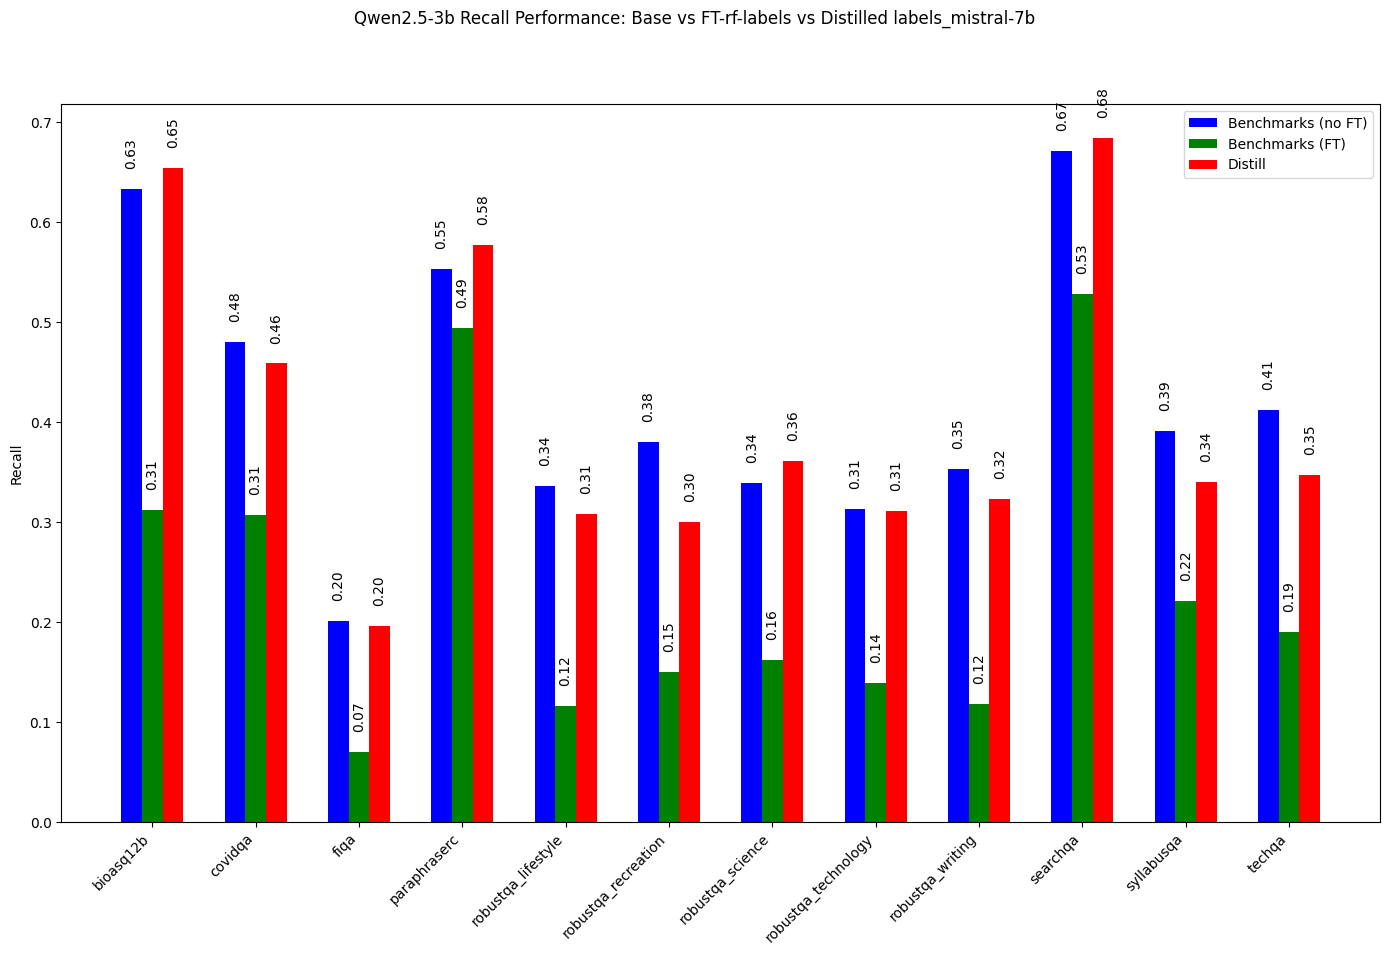

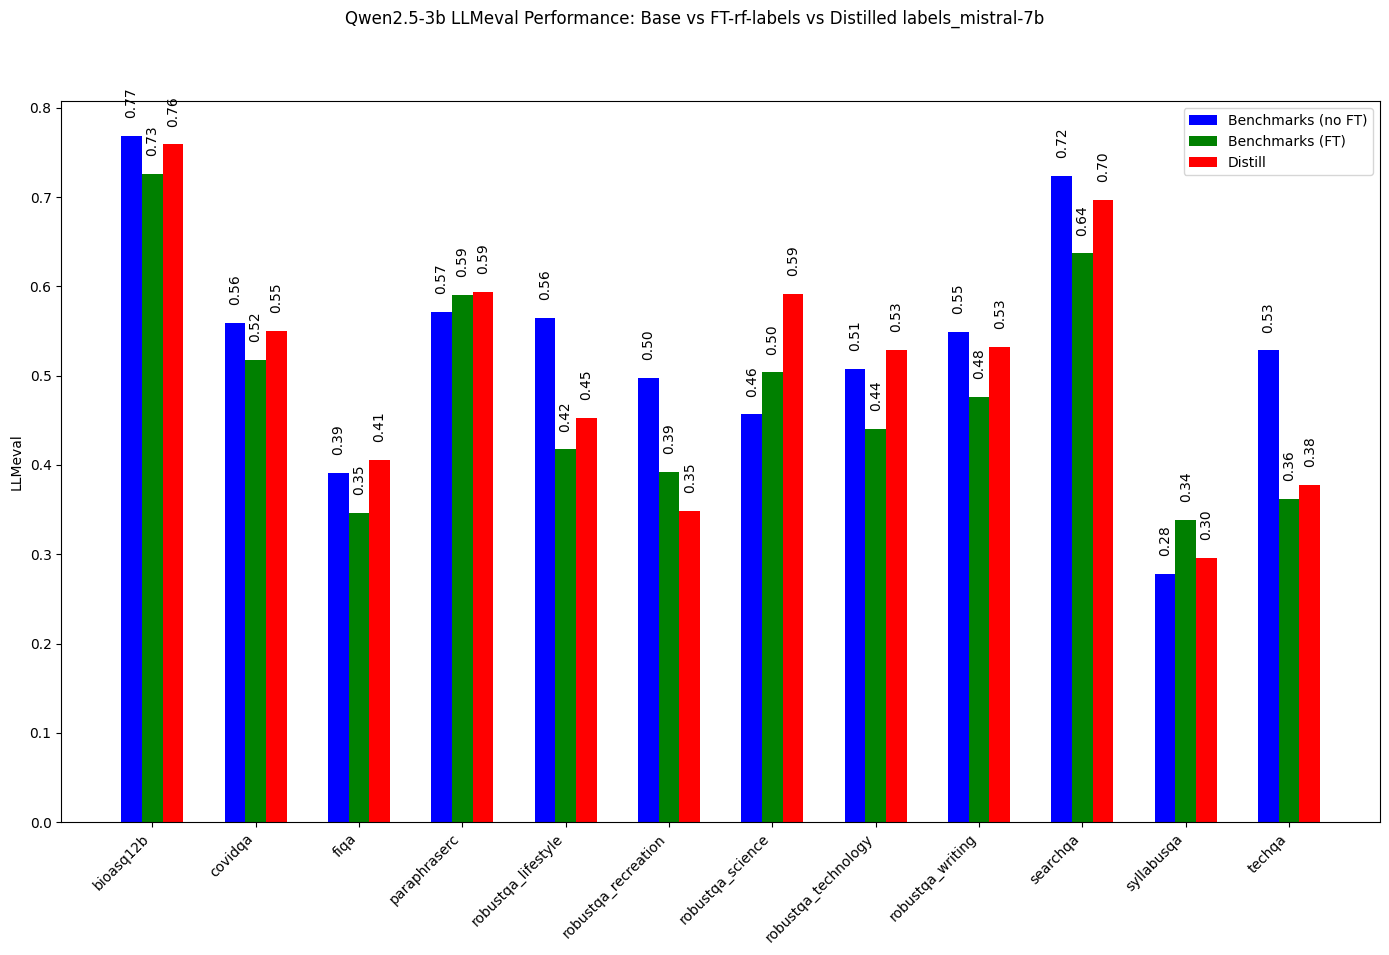

In [5]:
benchmarks_dir = "experiments/benchmarks_qwen"
distill_dir = "experiments/benchmarks_qwen_FT_MultiQA_distilled_mistral7b"
FT_dir = "experiments/benchmarks_qwen_FT_MultiQA_rf_short"

# load all runs in both directories
benchmarks_runs = [f for f in os.listdir(benchmarks_dir) if os.path.isdir(os.path.join(benchmarks_dir, f)) and 'ret' not in f]
distill_runs = [f for f in os.listdir(distill_dir) if os.path.isdir(os.path.join(distill_dir, f))]
ft_runs = [f for f in os.listdir(FT_dir) if os.path.isdir(os.path.join(FT_dir, f))]

def collect_experiment_data(dir, experiments=None):
    matchs, recalls, llmevals = dict(), dict(), dict()
    if experiments is None:
        for d in dir:
            with open(os.path.join(d, 'eval_dev_metrics.json'), 'r') as json_file:
                metrics = json.load(json_file)
            dataset_name = d.split('/')[1]
            matchs[dataset_name] = metrics['M']
            recalls[dataset_name] = metrics['Recall']
            llmevals[dataset_name] = float(metrics['LLMeval_llama3.1:70b']) if 'LLMeval_llama3.1:70b' in metrics else 0.0
    else:
        for experiment in experiments:
            if experiment.startswith('robustqa'):
                dataset_name = 'robustqa_' + experiment.split('_')[1]
            else:
                dataset_name = experiment.split('_')[0]
            with open(os.path.join(dir, experiment, 'eval_dev_metrics.json'), 'r') as json_file:
                metrics = json.load(json_file)
            matchs[dataset_name] = metrics['M']
            recalls[dataset_name] = metrics['Recall']
            llmevals[dataset_name] = float(metrics['LLMeval_llama3.1:70b']) if 'LLMeval_llama3.1:70b' in metrics else 0.0
    return matchs, recalls, llmevals

# Collect data for benchmarks and distill experiments
benchmarks_matches, benchmarks_recalls, benchmarks_llmevals = collect_experiment_data(benchmarks_dir, benchmarks_runs)
distill_matches, distill_recalls, distill_llmevals = collect_experiment_data(distill_dir, distill_runs)
ft_matches, ft_recalls, ft_llmevals = collect_experiment_data(FT_dir, ft_runs)

def plot_metrics_bar_subplots(metric_name, benchmarks_data, benchmarks_FT_data, distill_data, title):

    # sort data alphabetically by dataset name
    benchmarks_data = dict(sorted(benchmarks_data.items()))
    benchmarks_FT_data = dict(sorted(benchmarks_FT_data.items()))
    distill_data = dict(sorted(distill_data.items()))
    
    fig, ax = plt.subplots(figsize=(14, 10))

    bar_width = 0.2
    x = np.arange(len(benchmarks_data.keys()))

    # Plot bars for benchmarks and distill for the dataset
    bar0 = ax.bar(x - bar_width, benchmarks_data.values(), bar_width, label='Benchmarks (no FT)', color='b')
    bar1 = ax.bar(x, benchmarks_FT_data.values(), bar_width, label='Benchmarks (FT)', color='g')
    bar2 = ax.bar(x + bar_width, distill_data.values(), bar_width, label='Distill', color='r')

    for bar in [bar0, bar1, bar2]:
        for rect in bar:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)

    # Configure plot for the dataset
    ax.set_xticks(x)
    ax.set_xticklabels(benchmarks_data.keys(), rotation=45, ha="right")
    ax.set_ylabel(metric_name)
    ax.legend()

    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit title
    plt.savefig(f"tmp/figs/{title.replace(' ', '_').replace(':', '_')}.png")
    plt.show()

# Plot the results using bar plots with subplots for 4 datasets
plot_metrics_bar_subplots('Match', benchmarks_matches, ft_matches, distill_matches, 'Qwen2.5-3b Match Performance: Base vs FT-rf-labels vs Distilled labels_mistral-7b')
plot_metrics_bar_subplots('Recall', benchmarks_recalls, ft_recalls, distill_recalls, 'Qwen2.5-3b Recall Performance: Base vs FT-rf-labels vs Distilled labels_mistral-7b')
plot_metrics_bar_subplots('LLMeval', benchmarks_llmevals, ft_llmevals, distill_llmevals, 'Qwen2.5-3b LLMeval Performance: Base vs FT-rf-labels vs Distilled labels_mistral-7b')

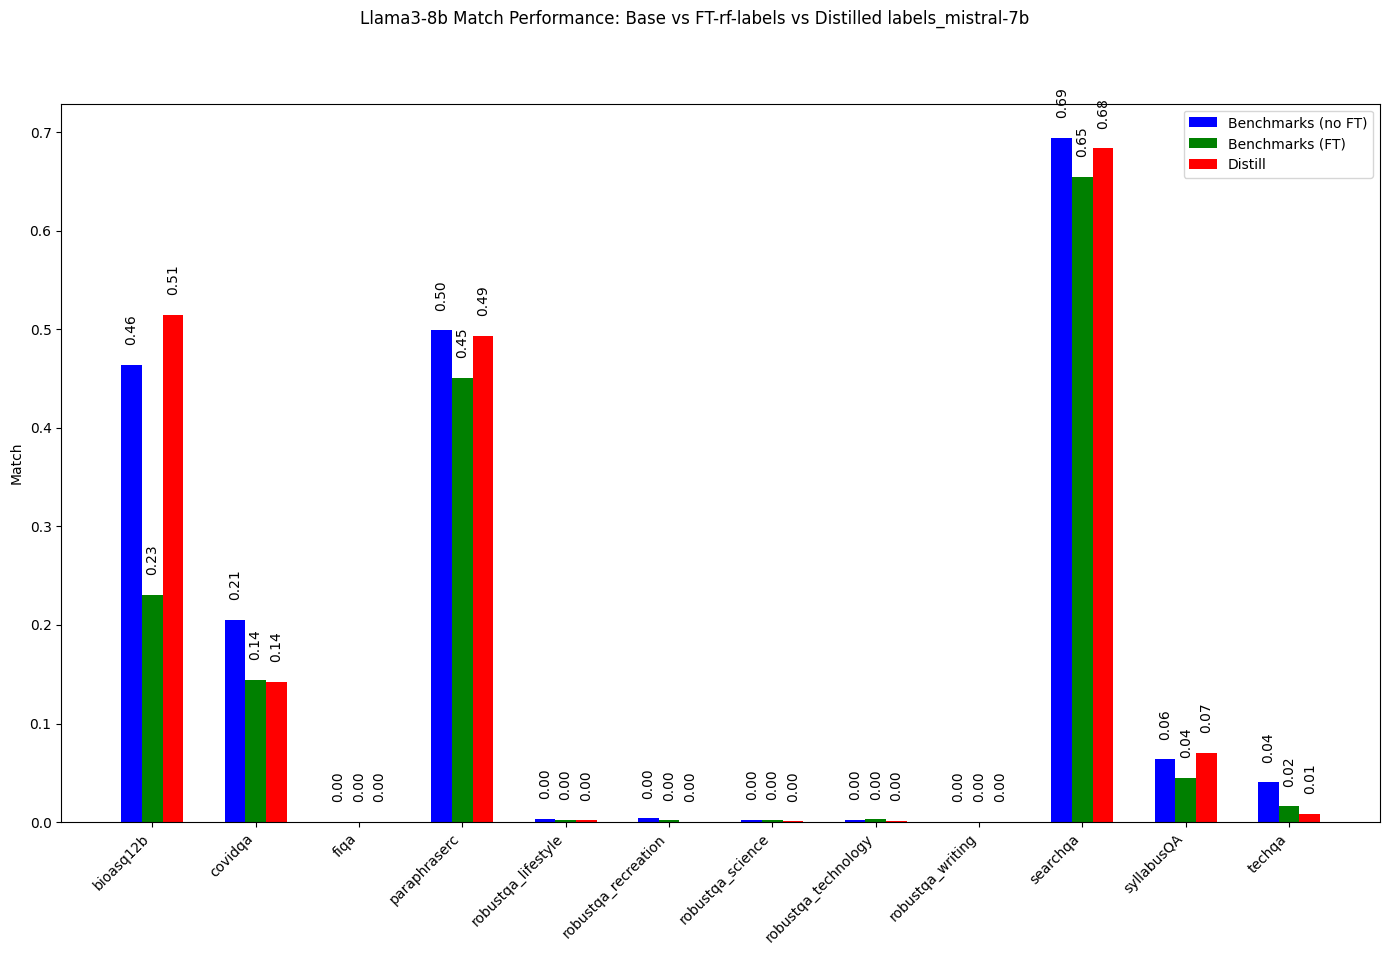

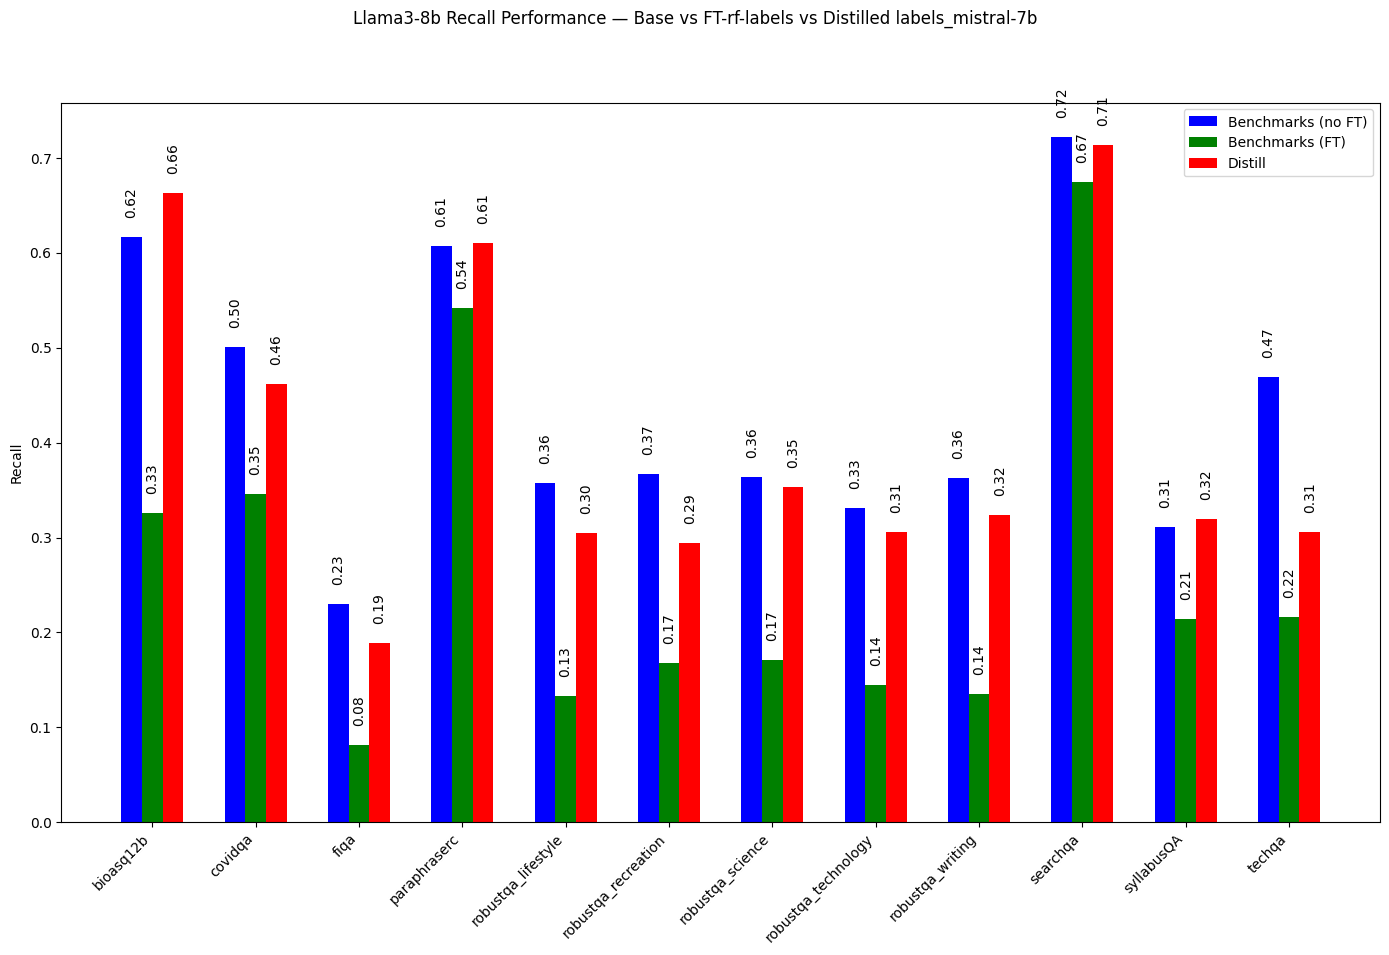

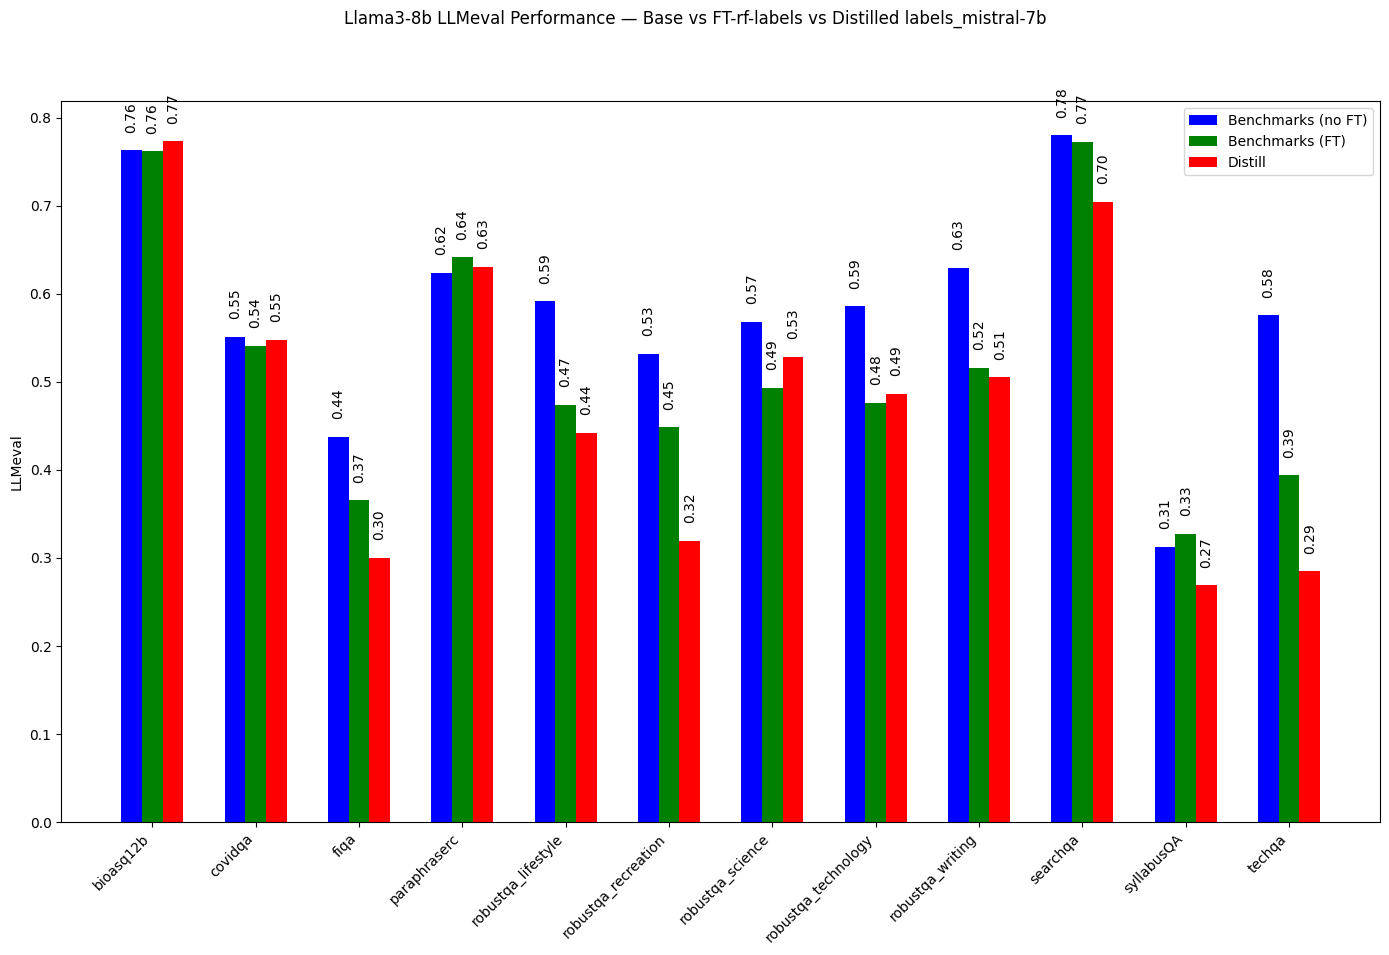

In [7]:
distill_dir = "experiments/benchmarks_llama_FT_MultiQA_distilled_mistral7b"
distill_runs = [f for f in os.listdir(distill_dir) if os.path.isdir(os.path.join(distill_dir, f))]
standard_FT_runs = [
    "experiments/bioasq12b/ll38binstruct_splade_deberta_bioasqprompt_epochs/ll38binstruct_splade_deberta_bioasqprompt_2epoch",
    "experiments/covidqa/ll38binstruct_splade_deberta_covidqaprompt_epochs/ll38binstruct_splade_deberta_covidqaprompt_2epoch",
    "experiments/fiqa/ll38binstruct_splade_deberta_fiqaprompt_epochs/ll38binstruct_splade_deberta_fiqaprompt_2epoch",
    "experiments/paraphraserc/ll38binstruct_splade_deberta_paraphrasercprompt_epochs/ll38binstruct_splade_deberta_paraphrasercprompt_2epoch",
    "experiments/robustqa_lifestyle/ll38binstruct_splade_deberta_lifestyleprompt_epochs/ll38binstruct_splade_deberta_techqaprompt_2epoch",
    "experiments/robustqa_recreation/ll38binstruct_splade_deberta_recreationprompt_epochs/ll38binstruct_splade_deberta_recreationprompt_2epoch",
    "experiments/robustqa_science/ll38binstruct_splade_deberta_scienceprompt_epochs/ll38binstruct_splade_deberta_scienceprompt_2epoch",
    "experiments/robustqa_technology/ll38binstruct_splade_deberta_technologyprompt_epochs/ll38binstruct_splade_deberta_technologyprompt_2epoch",
    "experiments/robustqa_writing/ll38binstruct_splade_deberta_writingprompt_epochs/ll38binstruct_splade_deberta_writingprompt_2epoch",
    "experiments/searchqa/ll38binstruct_splade_deberta_searchqaprompt_epochs/ll38binstruct_splade_deberta_searchqaprompt_2epoch",
    "experiments/syllabusQA/ll38binstruct_splade_deberta_syllabusqaprompt_epochs/ll38binstruct_splade_deberta_syllabusqaprompt_2epoch",
    "experiments/techqa/ll38binstruct_splade_deberta_techqaprompt_epochs/ll38binstruct_splade_deberta_techqaprompt_2epoch",
]
benchmarks_llama_runs = [
    "experiments/bioasq12b/ll3_8b_splade_deberta_bioasqprompt_2",
    "experiments/covidqa/llama3_8b_splade_deberta_covidqaprompt",
    "experiments/fiqa/llama3_8b_splade_deberta_advprompt",
    "experiments/paraphraserc/llama3_8b_splade_deberta_advprompt",
    "experiments/robustqa_lifestyle/llama3_8b_splade_deberta_lifestyleprompt",
    "experiments/robustqa_recreation/llama3_8b_splade_deberta_recreationprompt",
    "experiments/robustqa_science/llama3_8b_splade_deberta_scienceprompt",
    "experiments/robustqa_technology/llama3_8b_splade_deberta_techprompt",
    "experiments/robustqa_writing/llama3_8b_splade_deberta_writingprompt",
    "experiments/searchqa/llama3_8b_splade_deberta_techprompt",
    "experiments/syllabusQA/llama3_8b_splade_deberta_syllqaprompt",
    "experiments/techqa/llama3_8b_splade_deberta_techprompt",
]

def collect_experiment_data(dir, experiments=None):
    matchs, recalls, llmevals = dict(), dict(), dict()
    if experiments is None:
        for d in dir:
            with open(os.path.join(d, 'eval_dev_metrics.json'), 'r') as json_file:
                metrics = json.load(json_file)
            dataset_name = d.split('/')[1]
            matchs[dataset_name] = metrics['M']
            recalls[dataset_name] = metrics['Recall']
            llmevals[dataset_name] = float(metrics['LLMeval_llama3.1:70b'])
    else:
        for experiment in experiments:
            if experiment.startswith('robustqa'):
                dataset_name = 'robustqa_' + experiment.split('_')[1]
            else:
                dataset_name = experiment.split('_')[0]
            with open(os.path.join(dir, experiment, 'eval_dev_metrics.json'), 'r') as json_file:
                metrics = json.load(json_file)
            matchs[dataset_name] = metrics['M']
            recalls[dataset_name] = metrics['Recall']
            llmevals[dataset_name] = float(metrics['LLMeval_llama3.1:70b'])
    return matchs, recalls, llmevals

# Collect data for benchmarks and distill experiments
benchmarks_matches, benchmarks_recalls, benchmarks_llmevals = collect_experiment_data(benchmarks_llama_runs)
benchmarks_FT_matches, benchmarks_FT_recalls, benchmarks_FT_llmevals = collect_experiment_data(standard_FT_runs)
distill_matches, distill_recalls, distill_llmevals = collect_experiment_data(distill_dir, distill_runs)

# plot a recall and llmeval bar plot pairing benchmarks and distill next to each other for each dataset

def plot_metrics_bar_subplots(metric_name, benchmarks_data, benchmarks_FT_data, distill_data, title):

    # sort data alphabetically by dataset name
    benchmarks_data = dict(sorted(benchmarks_data.items()))
    benchmarks_FT_data = dict(sorted(benchmarks_FT_data.items()))
    distill_data = dict(sorted(distill_data.items()))
    
    fig, ax = plt.subplots(figsize=(14, 10))

    bar_width = 0.2
    x = np.arange(len(benchmarks_data.keys()))

    # Plot bars for benchmarks and distill for the dataset
    bar0 = ax.bar(x - bar_width, benchmarks_data.values(), bar_width, label='Benchmarks (no FT)', color='b')
    bar1 = ax.bar(x, benchmarks_FT_data.values(), bar_width, label='Benchmarks (FT)', color='g')
    bar2 = ax.bar(x + bar_width, distill_data.values(), bar_width, label='Distill', color='r')

    for bar in [bar0, bar1, bar2]:
        for rect in bar:
            height = rect.get_height()
            ax.text(rect.get_x() + rect.get_width() / 2.0, height + 0.02, f'{height:.2f}', ha='center', va='bottom', rotation=90)

    # Configure plot for the dataset
    ax.set_xticks(x)
    ax.set_xticklabels(benchmarks_data.keys(), rotation=45, ha="right")
    ax.set_ylabel(metric_name)
    ax.legend()

    fig.suptitle(title)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit title
    plt.savefig(f"tmp/figs/{title.replace(' ', '_').replace(':', '_')}.png")
    plt.show()

# Plot the results using bar plots with subplots for 4 datasets
plot_metrics_bar_subplots('Match', benchmarks_matches, benchmarks_FT_matches, distill_matches, 'Llama3-8b Match Performance: Base vs FT-rf-labels vs Distilled labels_mistral-7b')
plot_metrics_bar_subplots('Recall', benchmarks_recalls, benchmarks_FT_recalls, distill_recalls, 'Llama3-8b Recall Performance — Base vs FT-rf-labels vs Distilled labels_mistral-7b')
plot_metrics_bar_subplots('LLMeval', benchmarks_llmevals, benchmarks_FT_llmevals, distill_llmevals, 'Llama3-8b LLMeval Performance — Base vs FT-rf-labels vs Distilled labels_mistral-7b')

# Plot SOLAR-10.7B RAGChecker metrics on 6 benchmarks

In [4]:
def generate_spider_diagram(metrics_dict, filename=None):
    """
    Generate and overlap multiple spider diagrams for multiple datasets.
    
    Args:
        metrics_dict (dict): Dictionary where keys are dataset names and values are metrics.
        filename (str, optional): Path to save the resulting spider diagram.
    """
    categories = list(next(iter(metrics_dict.values())).keys())
    N = len(categories)

    # Angle for each axis in the spider plot
    angles = [n / float(N) * 2 * math.pi for n in range(N)]
    angles += angles[:1]  # close the loop

    # Set up the figure
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    plt.xticks(angles[:-1], categories, color='black', size=15)
    ax.tick_params(axis='x', pad=30)
    ax.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], color="grey", size=10)
    plt.ylim(0, 1)

    # Define a color palette
    colors = plt.cm.Paired(np.linspace(0, 1, len(metrics_dict)))

    # Plot each dataset's metrics
    for (dataset, metrics), color in zip(metrics_dict.items(), colors):
        values = list(metrics.values())
        values += values[:1]  # close the loop
        ax.plot(angles, values, linewidth=1.5, linestyle='solid', label=dataset, color=color)
        ax.fill(angles, values, color=color, alpha=0.1)

    # Add legend
    ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.0), fontsize=15)

    # Save or show the plot
    if filename:
        plt.title("RAGChecker Metrics for SOLAR-10.7B (spladeberta document chunks), across datasets", size=18)
        plt.savefig(filename, bbox_inches='tight')
        plt.clf()
    else:
        plt.show()

root = "experiments/runs_hackathon/solar"
all_metrics = {}

def parse(met):
    out = dict()
    # add overall_metrics keys
    for key, value in met["overall_metrics"].items():
        out[key.replace("_", " ") + r"$\uparrow$"] = value
    # add generator_metrics keys
    for key, value in met["generator_metrics"].items():
        if key not in ["relevant_noise_sensitivity", "irrelevant_noise_sensitivity"]:
            out[key.replace("_", " ") + r"$\uparrow$"] = value
        else:
            out[key.replace("_", " ") + r"$\downarrow$"] = value
    # add retriever metrics
    for key, value in met["retriever_metrics"].items():
        out[key.replace("_", " ") + r"$\uparrow$"] = value
    return out



In [ ]:

for subdir in os.listdir(root):
    if subdir.endswith("solar107b"):
        dataset = subdir.split("/")[-1].split("_")[0]
        metrics_file = f"{root}/{subdir}/ragchecker_dev_metrics_qwen.json"
        with open(metrics_file, "r") as f:
            metrics = json.load(f)
            all_metrics[dataset] = parse(metrics)

# Generate and show/save the spider diagram for all datasets
output_file = "tmp/figs/ragchecker_benchmarks.png"
generate_spider_diagram(all_metrics, filename=output_file)

In [5]:
root = "experiments/runs_hackathon/solar_generalprompt"
all_metrics = {}

for subdir in os.listdir(root):
    if subdir.endswith("solar107b"):
        dataset = subdir.split("/")[-1].split("_")[0]
        metrics_file = f"{root}/{subdir}/ragchecker_dev_metrics_qwen.json"
        with open(metrics_file, "r") as f:
            metrics = json.load(f)
            all_metrics[dataset] = parse(metrics)

# Generate and show/save the spider diagram for all datasets
output_file = "tmp/figs/ragchecker_benchmarks_selfknwlgprompt.png"
generate_spider_diagram(all_metrics, filename=output_file)

<Figure size 800x800 with 0 Axes>

# Visualize Lambdas through training across layers

In [30]:
base_model_path = "experiments/tune_diff_attn_learnlambda/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_base_init_alllayers/train/"

def lambda_init_fn(depth):
    return 0.8 - 0.6 * math.exp(-0.3 * depth)

def lambda_fn(lambda_q1, lambda_k1, lambda_q2, lambda_k2, lambda_init):
    lambda_1 = torch.exp(torch.sum(lambda_q1 * lambda_k1, dim=-1).float())
    lambda_2 = torch.exp(torch.sum(lambda_q2 * lambda_k2, dim=-1).float())
    lambda_full = lambda_1 - lambda_2 + lambda_init
    return lambda_full

lambdas_per_layer_per_chkpnt = defaultdict(list)
# first add the initial lambda values (checkpoint 0)
for layer in range(32):
    lambda_q1 = torch.zeros(128, dtype=torch.float32).normal_(mean=0,std=0.1)
    lambda_k1 = torch.zeros(128, dtype=torch.float32).normal_(mean=0,std=0.1)
    lambda_q2 = torch.zeros(128, dtype=torch.float32).normal_(mean=0,std=0.1)
    lambda_k2 = torch.zeros(128, dtype=torch.float32).normal_(mean=0,std=0.1)
    lambda_init = lambda_init_fn(layer)
    lambda_full = lambda_fn(lambda_q1, lambda_k1, lambda_q2, lambda_k2, lambda_init)
    lambdas_per_layer_per_chkpnt[layer].append(lambda_full)
# iterate over checkpoint folders
folders = sorted([os.path.join(base_model_path, e) for e in os.listdir(base_model_path)], key=lambda x: int(x.split('/')[-1].split('-')[-1]))
for model_path in folders:
    state_dict = safetensors.torch.load_file(os.path.join(model_path, "model.safetensors"))
    state_dict.keys()
    for layer in range(32):
        lambda_init = lambda_init_fn(layer)
        lambda_q1 = state_dict[f'model.layers.{layer}.self_attn.lambda_q1']
        lambda_k1 = state_dict[f'model.layers.{layer}.self_attn.lambda_k1']
        lambda_q2 = state_dict[f'model.layers.{layer}.self_attn.lambda_q2']
        lambda_k2 = state_dict[f'model.layers.{layer}.self_attn.lambda_k2']
        lambda_full = lambda_fn(lambda_q1, lambda_k1, lambda_q2, lambda_k2, lambda_init)
        lambdas_per_layer_per_chkpnt[layer].append(lambda_full)

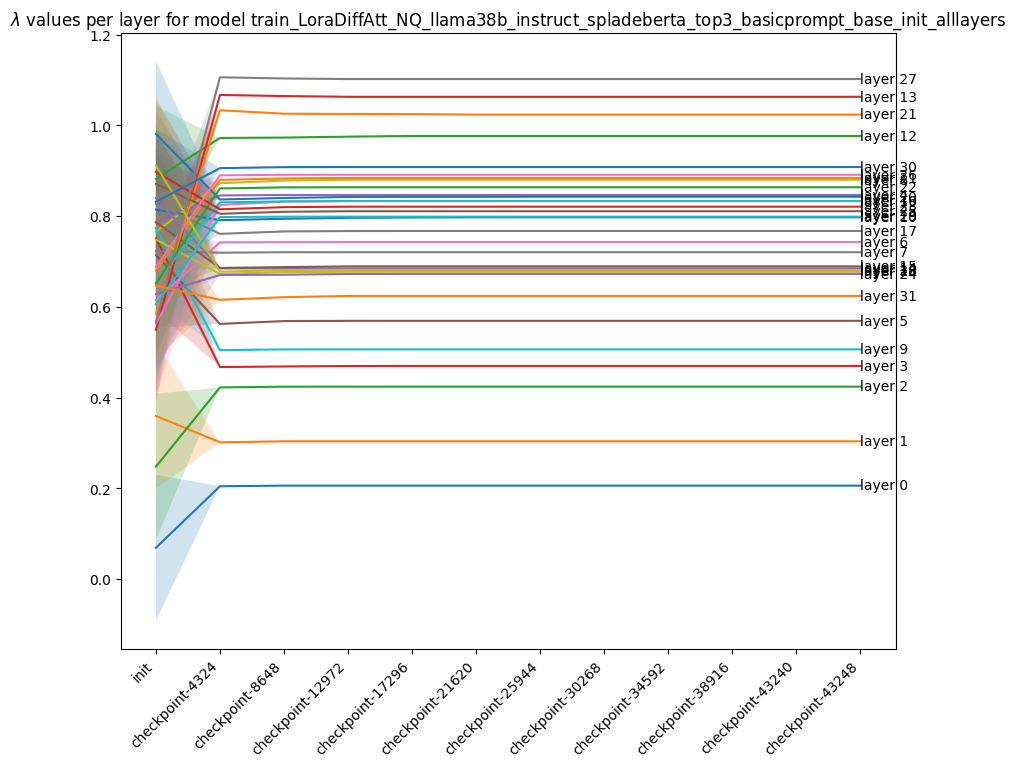

In [40]:
# plot the lambda values for each layer in each checkpoint
# x axis is the checkpoint value (sorted by checkpoint name)
# y axis is lambda value, one line for each layer
# plot a line for each layer
# x axis is the checkpoint number

fig, ax = plt.subplots(figsize=(10, 8))
x = np.arange(len(folders)+1)
for layer in range(32):
    y = np.array([lambdas_per_layer_per_chkpnt[layer][0]] + [lambdas_per_layer_per_chkpnt[layer][i+1].item() for i in range(len(folders))])
    ax.plot(x, y, label=f'layer {layer}')
    std_dev = np.array([0.161] + [0 for _ in range(len(folders))])
    ax.fill_between(x, y - std_dev, y + std_dev, alpha=0.2)
    # write on the line the layer number
    ax.text(x[-1], lambdas_per_layer_per_chkpnt[layer][-1].item(), f'layer {layer}', ha='left', va='center')
ax.set_xticks(x)
ax.set_xticklabels(["init"]+[e.split('/')[-1] for e in folders], rotation=45, ha="right")
plt.title(f"$\lambda$ values per layer for model {base_model_path.split('/')[-3]}")
plt.show()

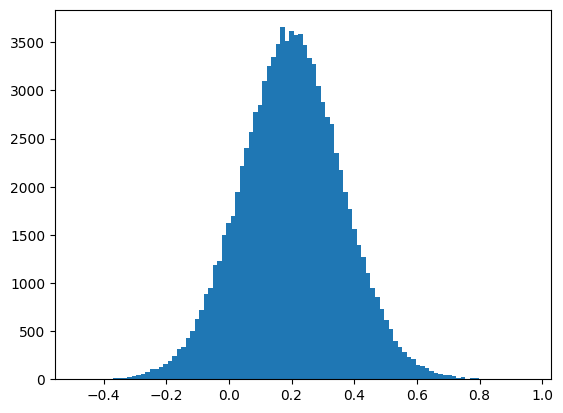

In [34]:
layer = 0
lamda_fulls = []
for i in range(100000):
    lambda_q1 = torch.zeros(128, dtype=torch.float32).normal_(mean=0,std=0.1)
    lambda_k1 = torch.zeros(128, dtype=torch.float32).normal_(mean=0,std=0.1)
    lambda_q2 = torch.zeros(128, dtype=torch.float32).normal_(mean=0,std=0.1)
    lambda_k2 = torch.zeros(128, dtype=torch.float32).normal_(mean=0,std=0.1)
    lambda_init = lambda_init_fn(layer)
    lambda_full = lambda_fn(lambda_q1, lambda_k1, lambda_q2, lambda_k2, lambda_init)
    lamda_fulls.append(lambda_full)

plt.hist(lamda_fulls, bins=100)
plt.show()

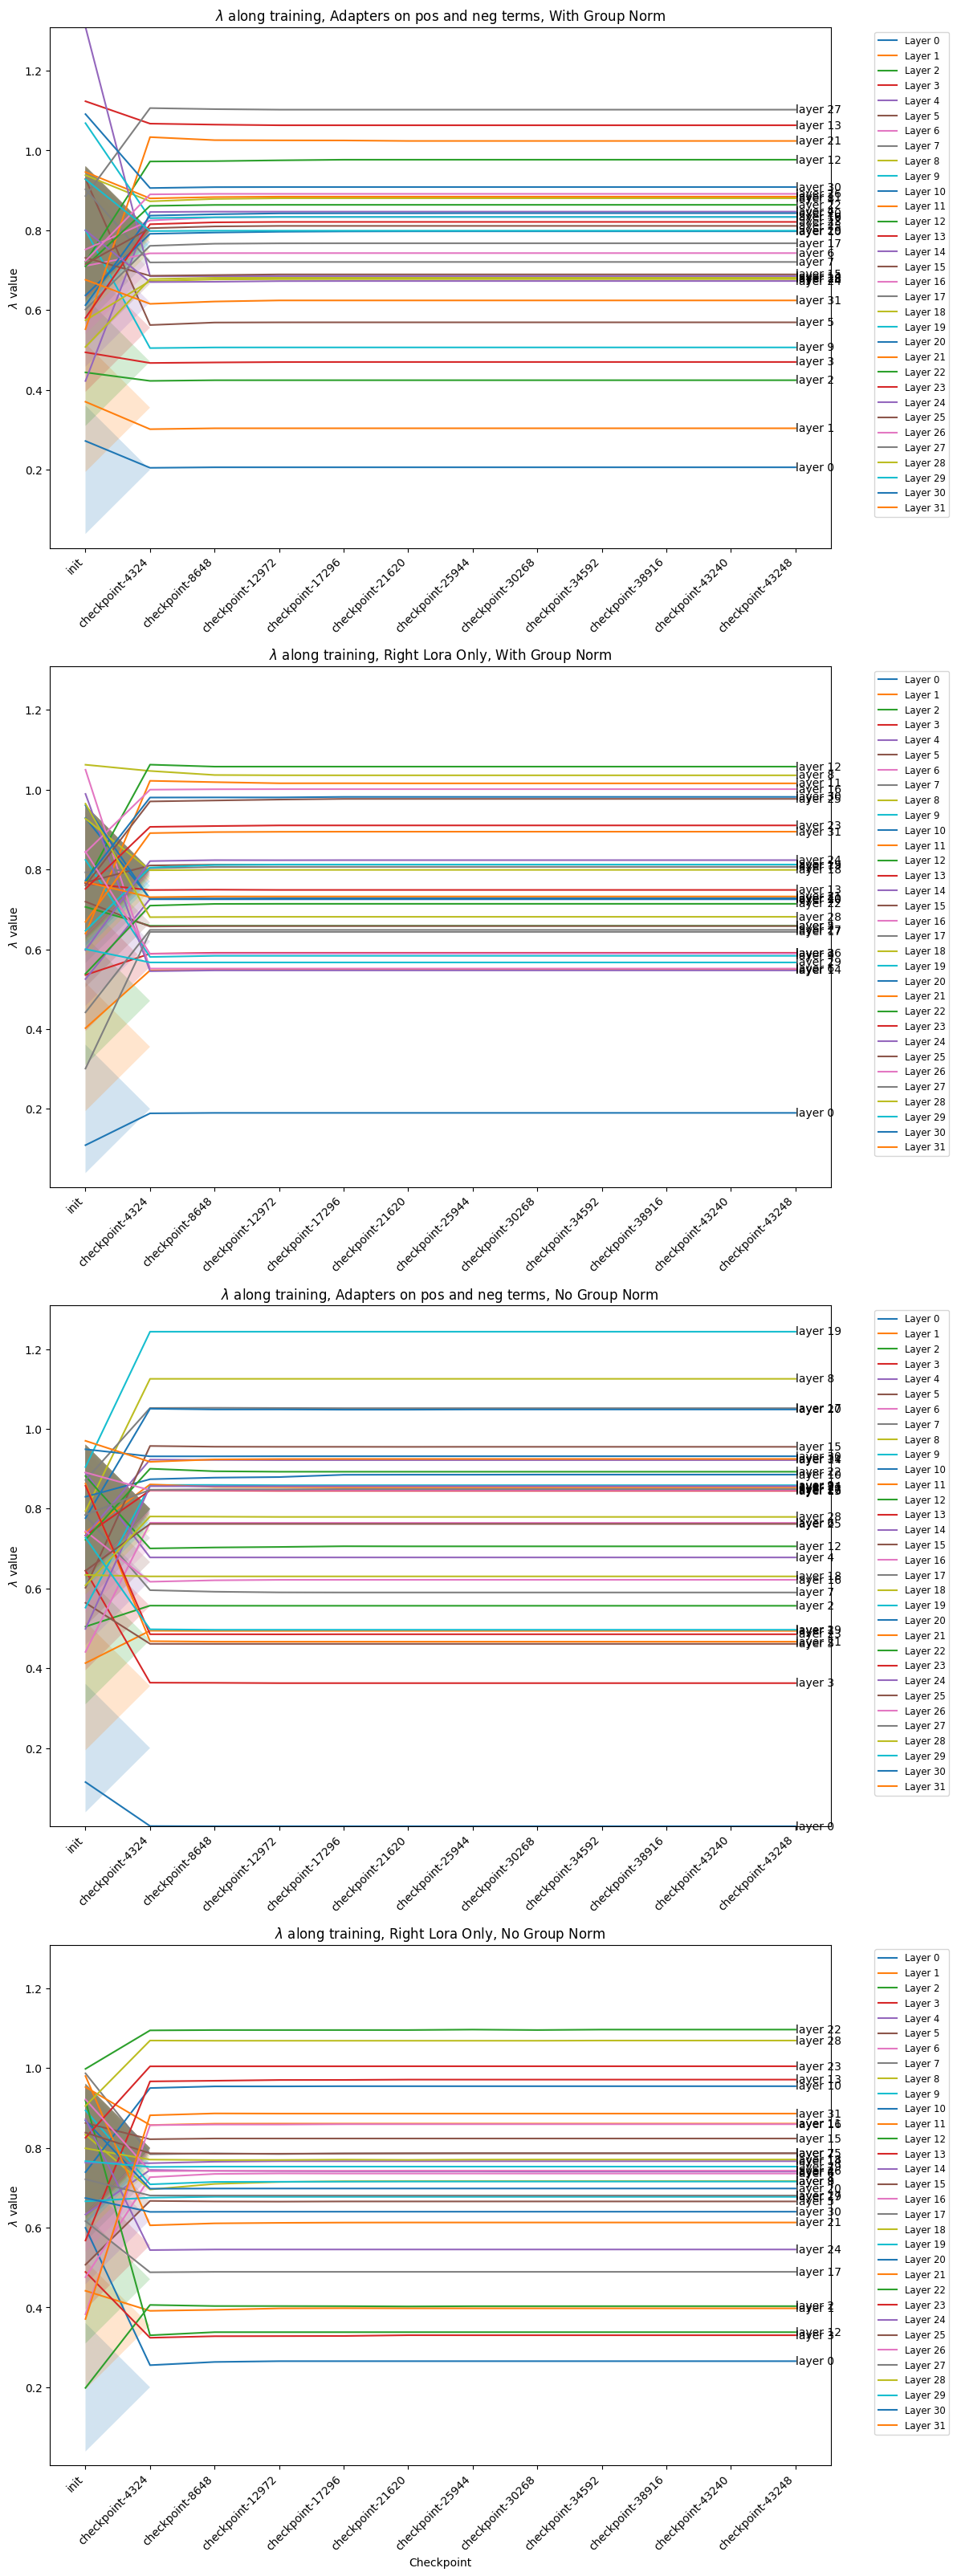

In [53]:
import os
import math
import torch
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import safetensors.torch

# Define functions for lambda calculations
def lambda_init_fn(depth):
    return 0.8 - 0.6 * math.exp(-0.3 * depth)

def lambda_fn(lambda_q1, lambda_k1, lambda_q2, lambda_k2, lambda_init):
    lambda_1 = torch.exp(torch.sum(lambda_q1 * lambda_k1, dim=-1).float())
    lambda_2 = torch.exp(torch.sum(lambda_q2 * lambda_k2, dim=-1).float())
    lambda_full = lambda_1 - lambda_2 + lambda_init
    return lambda_full

# Define multiple base model paths
base_model_paths = [
    "experiments/tune_diff_attn_learnlambda/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_base_init_alllayers",
    "experiments/tune_diff_attn_learnlambda/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_base_init_alllayers_rightloraonly",
    "experiments/tune_diff_attn_learnlambda_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_base_init_alllayers",
    "experiments/tune_diff_attn_learnlambda_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_base_init_alllayers_rightloraonly",
]
base_model_paths = [os.path.join(e, 'train/') for e in base_model_paths]

# Process each base model path
global_min, global_max = float('inf'), float('-inf')
lambdas_data = {}

for base_model_path in base_model_paths:
    lambdas_per_layer_per_chkpnt = defaultdict(list)
    
    # Add initial lambda values (checkpoint 0)
    for layer in range(32):
        lambda_q1 = torch.zeros(128, dtype=torch.float32).normal_(mean=0, std=0.1)
        lambda_k1 = torch.zeros(128, dtype=torch.float32).normal_(mean=0, std=0.1)
        lambda_q2 = torch.zeros(128, dtype=torch.float32).normal_(mean=0, std=0.1)
        lambda_k2 = torch.zeros(128, dtype=torch.float32).normal_(mean=0, std=0.1)
        lambda_init = lambda_init_fn(layer)
        lambda_full = lambda_fn(lambda_q1, lambda_k1, lambda_q2, lambda_k2, lambda_init)
        lambdas_per_layer_per_chkpnt[layer].append(lambda_full)
        global_min = min(global_min, lambda_full.item())
        global_max = max(global_max, lambda_full.item())
    
    # Iterate over checkpoint folders
    folders = sorted(
        [os.path.join(base_model_path, e) for e in os.listdir(base_model_path) if os.path.isdir(os.path.join(base_model_path, e))],
        key=lambda x: int(x.split('/')[-1].split('-')[-1])
    )
    for model_path in folders:
        state_dict = safetensors.torch.load_file(os.path.join(model_path, "model.safetensors"))
        for layer in range(32):
            lambda_init = lambda_init_fn(layer)
            lambda_q1 = state_dict[f'model.layers.{layer}.self_attn.lambda_q1']
            lambda_k1 = state_dict[f'model.layers.{layer}.self_attn.lambda_k1']
            lambda_q2 = state_dict[f'model.layers.{layer}.self_attn.lambda_q2']
            lambda_k2 = state_dict[f'model.layers.{layer}.self_attn.lambda_k2']
            lambda_full = lambda_fn(lambda_q1, lambda_k1, lambda_q2, lambda_k2, lambda_init)
            lambdas_per_layer_per_chkpnt[layer].append(lambda_full)
            global_min = min(global_min, lambda_full.item())
            global_max = max(global_max, lambda_full.item())
    
    lambdas_data[base_model_path] = (lambdas_per_layer_per_chkpnt, folders)

# Plot results
fig, axes = plt.subplots(len(base_model_paths), 1, figsize=(12, 8 * len(base_model_paths)), sharey=True)

for i, base_model_path in enumerate(base_model_paths):
    ax = axes[i] if len(base_model_paths) > 1 else axes
    lambdas_per_layer_per_chkpnt, folders = lambdas_data[base_model_path]
    
    x = np.arange(len(folders) + 1)
    for layer in range(32):
        y = np.array([lambdas_per_layer_per_chkpnt[layer][0].item()] + 
                     [lambdas_per_layer_per_chkpnt[layer][j + 1].item() for j in range(len(folders))])
        ax.plot(x, y, label=f'Layer {layer}')
        std_dev = np.array([0.161] + [0 for _ in range(len(folders))])
        ax.fill_between(x, lambda_init_fn(layer) - std_dev, lambda_init_fn(layer) + std_dev, alpha=0.2)
        # write on the line the layer number
        ax.text(x[-1], lambdas_per_layer_per_chkpnt[layer][-1].item(), f'layer {layer}', ha='left', va='center')
        
    ax.set_xticks(x)
    ax.set_xticklabels(["init"] + [e.split('/')[-1] for e in folders], rotation=45, ha="right")
    ax.set_ylim(global_min, global_max)
    title = ""
    if "rightloraonly" in base_model_path:
        title += "Right Lora Only, "
    else:
        title += "Adapters on pos and neg terms, "
    if "nogroupnorm" in base_model_path:
        title += "No Group Norm "
    else:
        title += "With Group Norm"
    ax.set_title(f"$\lambda$ along training, {title}")
    ax.set_ylabel("$\lambda$ value")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

plt.tight_layout()
plt.xlabel("Checkpoint")
plt.savefig("diff_attn_lambda_values_along_training_per_layer.png")
plt.show()

# Evaluate multidomain

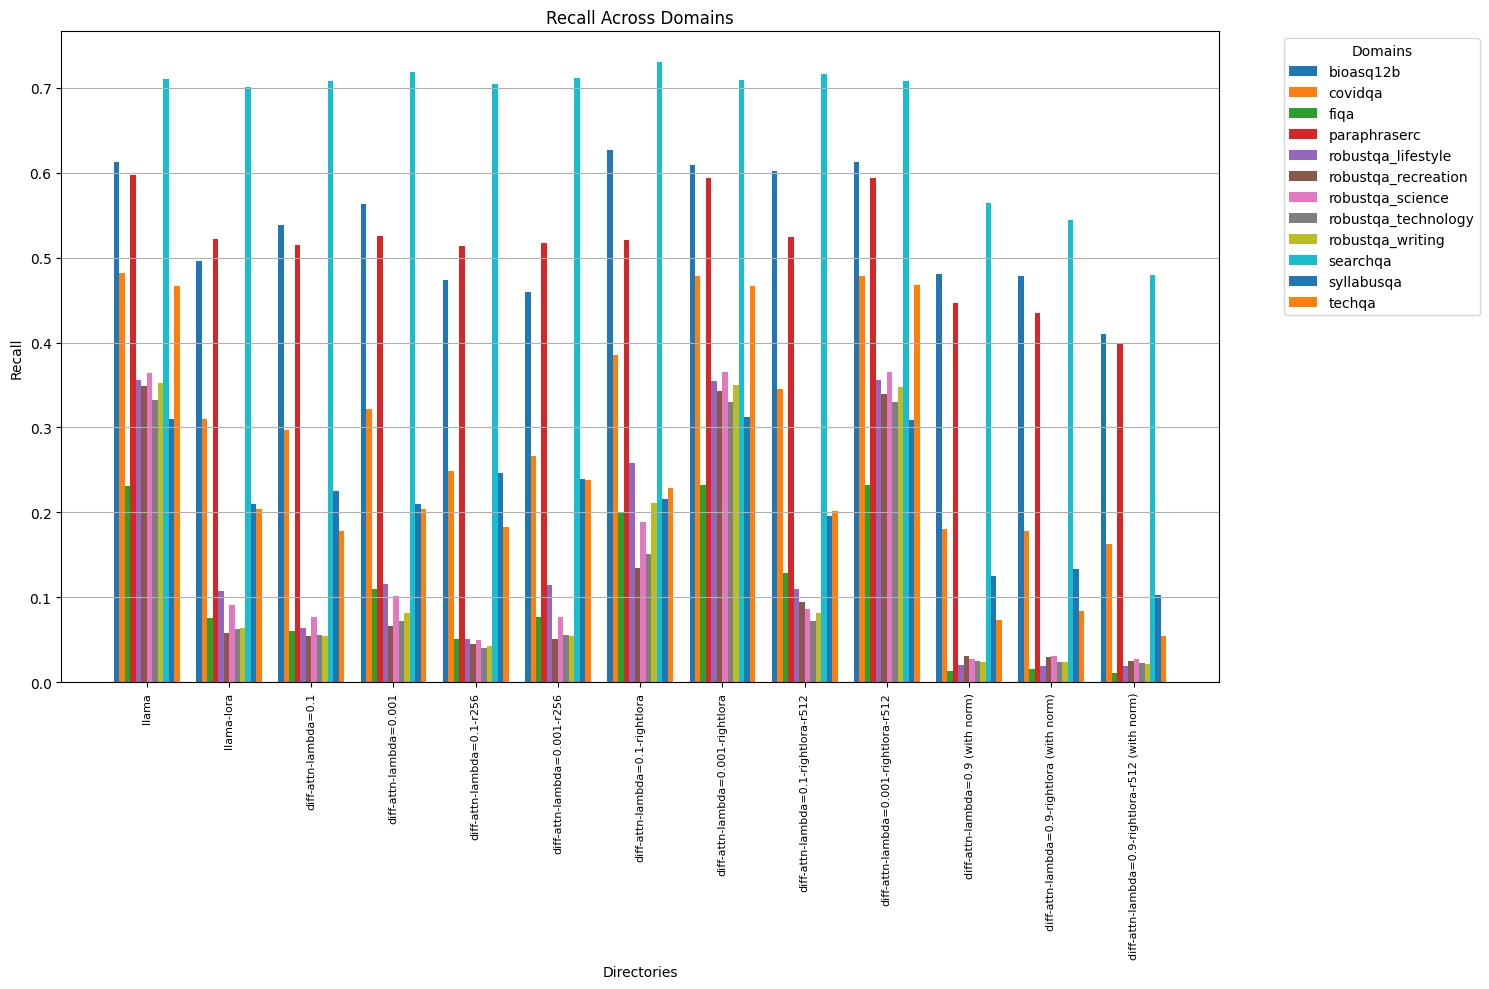

In [3]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np

# Directories and domains
domains = [
    "bioasq12b", "covidqa", "fiqa", "paraphraserc", "robustqa_lifestyle", 
    "robustqa_recreation", "robustqa_science", "robustqa_technology", "robustqa_writing", 
    "searchqa", "syllabusqa", "techqa"
]
dirs = """experiments/control_nq_llama/llama38binstruct_evaltop3 
experiments/control_nq_llama/train_Lora_NQ_llama38b_instruct_spladeberta_top3_basicprompt/eval_top3 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda01_base_init_alllayers/eval 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda0001_base_init_alllayers/eval 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda01_base_init_alllayers_r256/eval 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda0001_base_init_alllayers_r256/eval 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda01_base_init_alllayers_rightloraonly/eval 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda0001_base_init_alllayers_rightloraonly/eval 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda01_base_init_alllayers_rightloraonly_r512/eval 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda0001_base_init_alllayers_rightloraonly_r512/eval 
experiments/tune_diff_attn_nq_lambda_spladeberta/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_lambda09_base_init_alllayers/eval 
experiments/tune_diff_attn_nq_lambda_spladeberta/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_lambda09_base_init_alllayers_rightloraonly/eval 
experiments/tune_diff_attn_nq_lambda_spladeberta/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_lambda09_base_init_alllayers_rightloraonly_r512/eval""".split()

labels = ["llama", "llama-lora", "diff-attn-lambda=0.1", "diff-attn-lambda=0.001", "diff-attn-lambda=0.1-r256", "diff-attn-lambda=0.001-r256", 
          "diff-attn-lambda=0.1-rightlora", "diff-attn-lambda=0.001-rightlora", "diff-attn-lambda=0.1-rightlora-r512", "diff-attn-lambda=0.001-rightlora-r512", 
          "diff-attn-lambda=0.9 (with norm)", "diff-attn-lambda=0.9-rightlora (with norm)", "diff-attn-lambda=0.9-rightlora-r512 (with norm)"]

# Initialize data storage
recall_data = {domain: [] for domain in domains}

# Extract Recall values for each domain
for i,dir in enumerate(dirs):
    for domain in domains:
        eval_file = os.path.join(dir, domain, "eval_dev_metrics.json")
        if os.path.exists(eval_file):
            with open(eval_file, "r") as f:
                metrics = json.load(f)
                recall = metrics.get("Recall", 0)
                recall_data[domain].append((labels[i], recall))
        else:
            recall_data[domain].append((labels[i], None))

# Plotting
plt.figure(figsize=(15, 10))
x_positions = np.arange(len(dirs))
bar_width = 0.8 / len(domains)  # Adjust bar width to fit all domains

for i, (domain, values) in enumerate(recall_data.items()):
    dirs, recalls = zip(*values)
    recalls = [r if r is not None else 0 for r in recalls]  # Replace None with 0
    
    plt.bar(x_positions + i * bar_width, recalls, bar_width, label=domain)

plt.xticks(x_positions + bar_width * (len(domains) / 2 - 0.5), dirs, rotation=90, fontsize=8)
plt.xlabel("Directories")
plt.ylabel("Recall")
plt.title("Recall Across Domains")
plt.legend(title="Domains", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(axis='y')

# Save the plot
# plt.savefig("figs/diff_attn_eval_domains_recall.png")
plt.show()

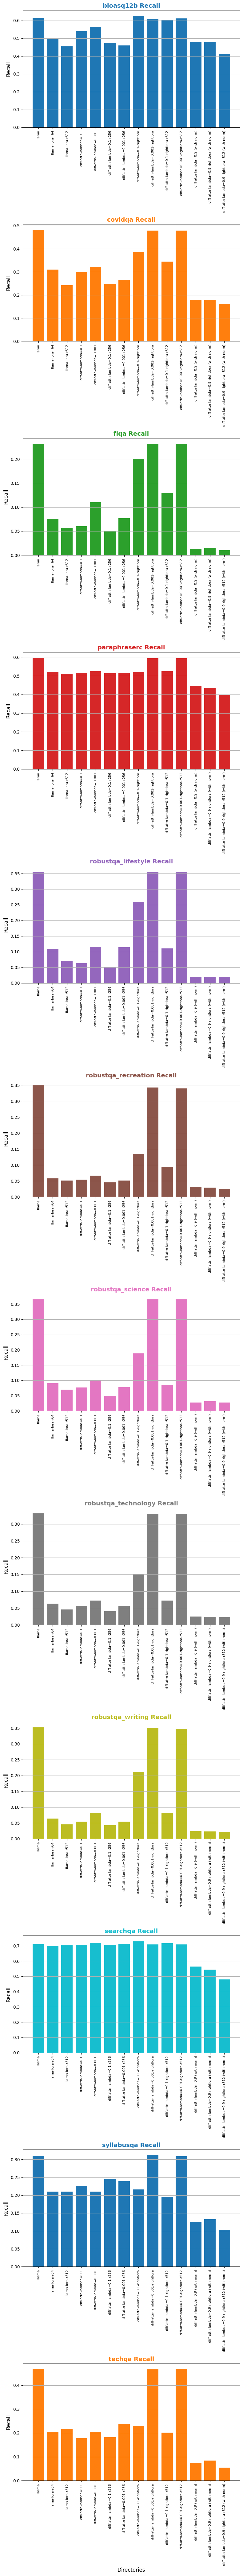

In [5]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np

# Directories and domains
domains = [
    "bioasq12b", "covidqa", "fiqa", "paraphraserc", "robustqa_lifestyle", 
    "robustqa_recreation", "robustqa_science", "robustqa_technology", "robustqa_writing", 
    "searchqa", "syllabusqa", "techqa"
]
dirs = """experiments/control_nq_llama/llama38binstruct_evaltop3 
experiments/control_nq_llama/train_Lora_NQ_llama38b_instruct_spladeberta_top3_basicprompt/eval_top3 
experiments/control_nq_llama/train_Lora_r512_NQ_llama38b_instruct_spladeberta_top3_basicprompt/eval_top3 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda01_base_init_alllayers/eval 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda0001_base_init_alllayers/eval 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda01_base_init_alllayers_r256/eval 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda0001_base_init_alllayers_r256/eval 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda01_base_init_alllayers_rightloraonly/eval 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda0001_base_init_alllayers_rightloraonly/eval 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda01_base_init_alllayers_rightloraonly_r512/eval 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda0001_base_init_alllayers_rightloraonly_r512/eval 
experiments/tune_diff_attn_nq_lambda_spladeberta/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_lambda09_base_init_alllayers/eval 
experiments/tune_diff_attn_nq_lambda_spladeberta/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_lambda09_base_init_alllayers_rightloraonly/eval 
experiments/tune_diff_attn_nq_lambda_spladeberta/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_lambda09_base_init_alllayers_rightloraonly_r512/eval""".split()

labels = ["llama", "llama-lora-r64", "llama-lora-r512", "diff-attn-lambda=0.1", "diff-attn-lambda=0.001", "diff-attn-lambda=0.1-r256", "diff-attn-lambda=0.001-r256", 
          "diff-attn-lambda=0.1-rightlora", "diff-attn-lambda=0.001-rightlora", "diff-attn-lambda=0.1-rightlora-r512", "diff-attn-lambda=0.001-rightlora-r512", 
          "diff-attn-lambda=0.9 (with norm)", "diff-attn-lambda=0.9-rightlora (with norm)", "diff-attn-lambda=0.9-rightlora-r512 (with norm)"]

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", "#1f77b4", "#ff7f0e"]

metric = "EM"
metric = "M"
metric = "Recall"
# Initialize data storage
recall_data = {domain: [] for domain in domains}

# Extract Recall values for each domain
for i,dir in enumerate(dirs):
    for domain in domains:
        eval_file = os.path.join(dir, domain, "eval_dev_metrics.json")
        if os.path.exists(eval_file):
            with open(eval_file, "r") as f:
                metrics = json.load(f)
                recall = metrics.get(metric, 0)
                recall_data[domain].append((labels[i], recall))
        else:
            recall_data[domain].append((labels[i], None))

# Plotting
num_domains = len(domains)
fig, axes = plt.subplots(num_domains, 1, figsize=(8, 7 * num_domains))

for i, (ax, (domain, values)) in enumerate(zip(axes, recall_data.items())):
    dirs, recalls = zip(*values)
    recalls = [r if r is not None else 0 for r in recalls]  # Replace None with 0
    
    x_positions = np.arange(len(dirs))
    ax.bar(x_positions, recalls, color=colors[i])
    ax.set_title(domain + " " + metric, fontsize=14, fontweight='bold', color=colors[i])
    ax.set_ylabel(metric, fontsize=12)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(dirs, rotation=90, fontsize=8)
    ax.grid(axis='y')

axes[-1].set_xlabel("Directories", fontsize=12)
plt.tight_layout()

# Save the plot
plt.savefig(f"figs/diff_attn_eval_domains_{metric}.png")
plt.show()

# Other

In [4]:
dirs = """experiments/nih_hash/llama38binstruct 
experiments/nih_hash/llama-lora-NQ 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda01_base_init_alllayers/eval/nih_hash 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda0001_base_init_alllayers/eval/nih_hash 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda01_base_init_alllayers_r256/eval/nih_hash 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda0001_base_init_alllayers_r256/eval/nih_hash 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda01_base_init_alllayers_rightloraonly/eval/nih_hash 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda0001_base_init_alllayers_rightloraonly/eval/nih_hash 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda01_base_init_alllayers_rightloraonly_r512/eval/nih_hash 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda0001_base_init_alllayers_rightloraonly_r512/eval/nih_hash 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda05_base_init_alllayers/eval/nih_hash 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda05_base_init_alllayers_r256/eval/nih_hash 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda05_base_init_alllayers_rightloraonly/eval/nih_hash 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda05_base_init_alllayers_rightloraonly_r512/eval/nih_hash 
experiments/tune_diff_attn_nq_lambda_spladeberta/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_lambda09_base_init_alllayers/eval/nih_hash 
experiments/tune_diff_attn_nq_lambda_spladeberta/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_lambda09_base_init_alllayers_rightloraonly/eval/nih_hash 
experiments/tune_diff_attn_nq_lambda_spladeberta/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_lambda09_base_init_alllayers_rightloraonly_r512/eval/nih_hash""".split()

labels = ["llama", "llama-lora", "diff-attn-lambda=0.1", "diff-attn-lambda=0.001", "diff-attn-lambda=0.1-r256", "diff-attn-lambda=0.001-r256", 
          "diff-attn-lambda=0.1-rightlora", "diff-attn-lambda=0.001-rightlora", "diff-attn-lambda=0.1-rightlora-r512", "diff-attn-lambda=0.001-rightlora-r512", 
          "diff-attn-lambda=0.5", "diff-attn-lambda=0.5-r256", "diff-attn-lambda=0.5-rightlora", "diff-attn-lambda=0.5-rightlora-r512",
          "diff-attn-lambda=0.9 (with norm)", "diff-attn-lambda=0.9-rightlora (with norm)", "diff-attn-lambda=0.9-rightlora-r512 (with norm)"]

nih_hash_matches = dict()
magic_phrase_attn_score = dict()

for i,dir in enumerate(dirs):
    eval_file = os.path.join(dir, "eval_dev_metrics.json")
    if os.path.exists(eval_file):
        with open(eval_file, "r") as f:
            metrics = json.load(f)
            nih_hash_matches[labels[i]] = metrics.get("M", 0)
            if "att" in metrics:
                magic_phrase_attn_score[labels[i]] = metrics["att"].get("att_last_magic", 0)
            elif "att_last_magic" in metrics:
                magic_phrase_attn_score[labels[i]] = metrics["att_last_magic"]
            else:
                print(f"Missing 'att' or 'att_last_magic' in {eval_file}")
                magic_phrase_attn_score[labels[i]] = "TBD"            
    else:
        print(f"Missing {eval_file}")
        nih_hash_matches[labels[i]] = "TBD"
        magic_phrase_attn_score[labels[i]] = "TBD"

# print ready for github markdown
print("| Checkpoint | NIH-hash match | Needle attn score |")
print("| --- | --- | --- |")
for label in labels:
    if nih_hash_matches[label] != "TBD" and magic_phrase_attn_score[label] != "TBD":
        print(f"| {label} | {nih_hash_matches[label]:.3f} | {magic_phrase_attn_score[label]:.6f} |")
    else:
        print(f"| {label} | {nih_hash_matches[label]} | {magic_phrase_attn_score[label]} |")

| Checkpoint | NIH-hash match | Needle attn score |
| --- | --- | --- |
| llama | 0.832 | 0.022339 |
| llama-lora | 0.029 | 0.019859 |
| diff-attn-lambda=0.1 | 0.018 | 0.018640 |
| diff-attn-lambda=0.001 | 0.035 | 0.018416 |
| diff-attn-lambda=0.1-r256 | 0.029 | 0.014105 |
| diff-attn-lambda=0.001-r256 | 0.006 | 0.015738 |
| diff-attn-lambda=0.1-rightlora | 0.297 | 0.020687 |
| diff-attn-lambda=0.001-rightlora | 0.828 | 0.019364 |
| diff-attn-lambda=0.1-rightlora-r512 | 0.078 | 0.016247 |
| diff-attn-lambda=0.001-rightlora-r512 | 0.826 | 0.019409 |
| diff-attn-lambda=0.5 | 0.002 | 0.015466 |
| diff-attn-lambda=0.5-r256 | 0.020 | 0.017435 |
| diff-attn-lambda=0.5-rightlora | 0.018 | 0.038563 |
| diff-attn-lambda=0.5-rightlora-r512 | 0.018 | 0.029331 |
| diff-attn-lambda=0.9 (with norm) | 0.025 | 0.002707 |
| diff-attn-lambda=0.9-rightlora (with norm) | 0.031 | 0.003057 |
| diff-attn-lambda=0.9-rightlora-r512 (with norm) | 0.012 | 0.001171 |


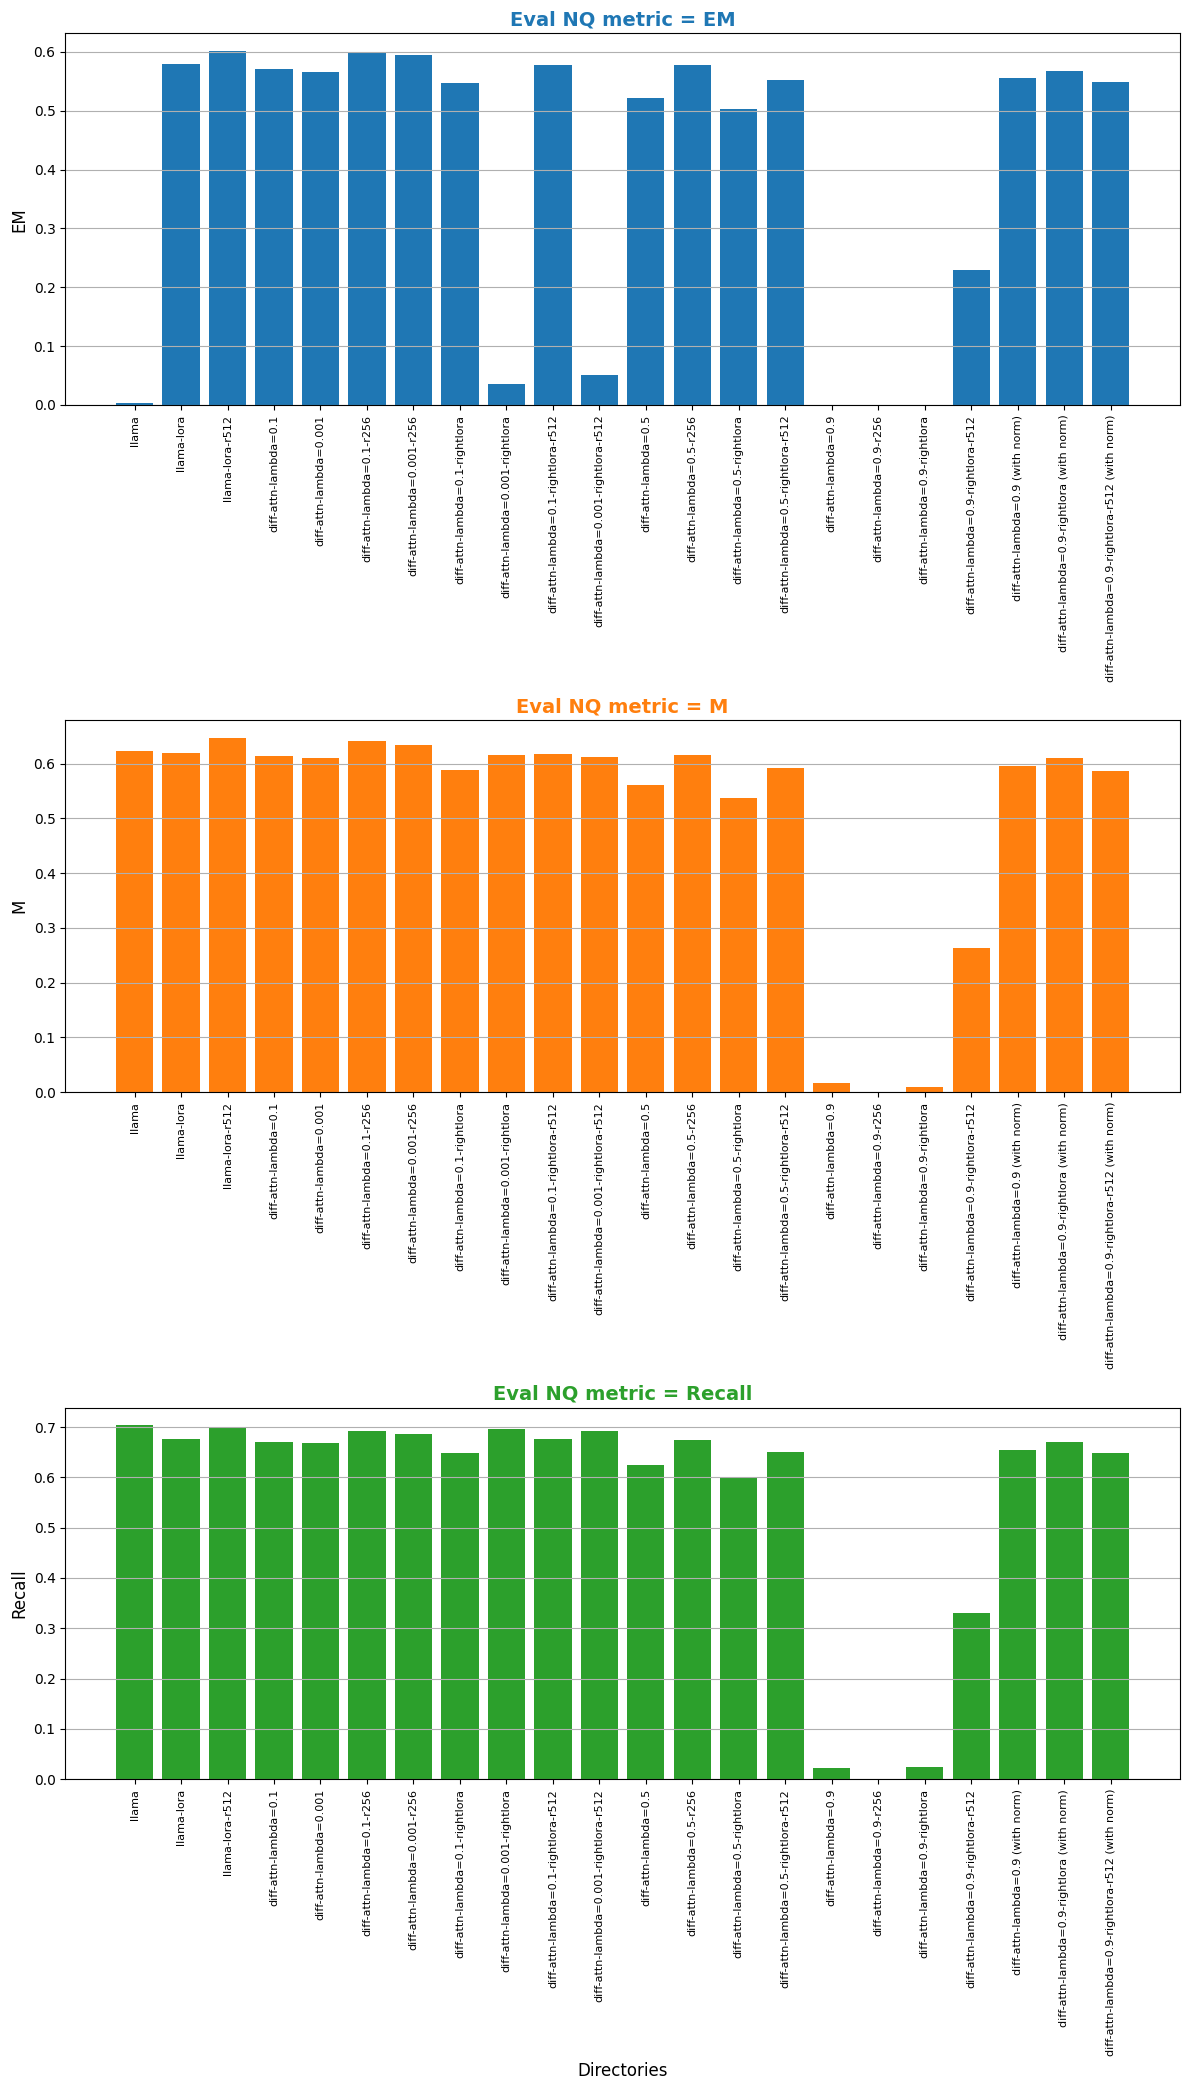

In [4]:
dirs = """experiments/control_nq_llama/eval_NQ_llama3_8b_instruct_spladeberta_basicprompt 
experiments/control_nq_llama/train_Lora_NQ_llama38b_instruct_spladeberta_top3_basicprompt 
experiments/control_nq_llama/train_Lora_r512_NQ_llama38b_instruct_spladeberta_top3_basicprompt 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda01_base_init_alllayers 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda0001_base_init_alllayers 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda01_base_init_alllayers_r256 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda0001_base_init_alllayers_r256 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda01_base_init_alllayers_rightloraonly 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda0001_base_init_alllayers_rightloraonly 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda01_base_init_alllayers_rightloraonly_r512 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda0001_base_init_alllayers_rightloraonly_r512 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda05_base_init_alllayers 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda05_base_init_alllayers_r256 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda05_base_init_alllayers_rightloraonly 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda05_base_init_alllayers_rightloraonly_r512 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda09_base_init_alllayers 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda09_base_init_alllayers_r256 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda09_base_init_alllayers_rightloraonly 
experiments/tune_diff_attn_nq_lambda_spladeberta_nogroupnorm/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_nogroupnorm_lambda09_base_init_alllayers_rightloraonly_r512 
experiments/tune_diff_attn_nq_lambda_spladeberta/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_lambda09_base_init_alllayers 
experiments/tune_diff_attn_nq_lambda_spladeberta/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_lambda09_base_init_alllayers_rightloraonly 
experiments/tune_diff_attn_nq_lambda_spladeberta/train_LoraDiffAtt_NQ_llama38b_instruct_spladeberta_top3_basicprompt_lambda09_base_init_alllayers_rightloraonly_r512""".split()

labels = ["llama", "llama-lora", "llama-lora-r512", "diff-attn-lambda=0.1", "diff-attn-lambda=0.001", "diff-attn-lambda=0.1-r256", "diff-attn-lambda=0.001-r256", 
          "diff-attn-lambda=0.1-rightlora", "diff-attn-lambda=0.001-rightlora", "diff-attn-lambda=0.1-rightlora-r512", "diff-attn-lambda=0.001-rightlora-r512", 
          "diff-attn-lambda=0.5", "diff-attn-lambda=0.5-r256", "diff-attn-lambda=0.5-rightlora", "diff-attn-lambda=0.5-rightlora-r512",
            "diff-attn-lambda=0.9", "diff-attn-lambda=0.9-r256", "diff-attn-lambda=0.9-rightlora", "diff-attn-lambda=0.9-rightlora-r512",
          "diff-attn-lambda=0.9 (with norm)", "diff-attn-lambda=0.9-rightlora (with norm)", "diff-attn-lambda=0.9-rightlora-r512 (with norm)"]

em = "EM"
m = "M"
recall = "Recall"
# Initialize data storage
data = {metric: [] for metric in [em, m, recall]}

for i,dir in enumerate(dirs):
    eval_file = os.path.join(dir, "eval_dev_metrics.json")
    if os.path.exists(eval_file):
        with open(eval_file, "r") as f:
            metrics = json.load(f)
            for metric in [em, m, recall]:
                value = metrics.get(metric, 0)
                data[metric].append((labels[i], value))
    else:
        for metric in [em, m, recall]:
            data[metric].append((labels[i], None))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", "#1f77b4", "#ff7f0e"]

# Plotting
num_metrics = len(data)
fig, axes = plt.subplots(num_metrics, 1, figsize=(12, 7 * num_metrics))

for i, (ax, (metric, values)) in enumerate(zip(axes, data.items())):
    dirs, metrics = zip(*values)
    metrics = [m if m is not None else 0 for m in metrics]  # Replace None with 0
    
    x_positions = np.arange(len(dirs))
    ax.bar(x_positions, metrics, color=colors[i])
    ax.set_title("Eval NQ metric = "+metric, fontsize=14, fontweight='bold', color=colors[i])
    ax.set_ylabel(metric, fontsize=12)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(dirs, rotation=90, fontsize=8)
    ax.grid(axis='y')

axes[-1].set_xlabel("Directories", fontsize=12)
plt.tight_layout()

# Save the plot
plt.savefig(f"figs/diff_attn_eval_NQ_metrics.png")
plt.show()


In [3]:
from datasets import load_from_disk
ds = load_from_disk("datasets/MultiQA_train")

In [4]:
ds

Dataset({
    features: ['id', 'content', 'label'],
    num_rows: 453023
})

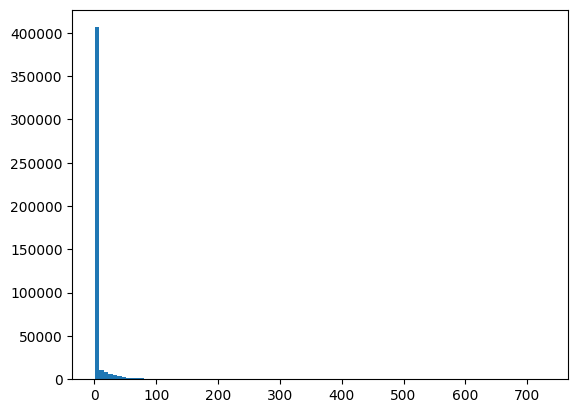

In [5]:
# plot dataset label lengths
import matplotlib.pyplot as plt
import numpy as np

label_lengths = [len(e) for e in ds['label']]
plt.hist(label_lengths, bins=100)
plt.show()

In [14]:
sorted(label_lengths)[-150:]

[254,
 256,
 256,
 256,
 256,
 256,
 257,
 258,
 258,
 259,
 259,
 261,
 263,
 263,
 264,
 265,
 267,
 270,
 270,
 272,
 273,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 280,
 282,
 282,
 283,
 283,
 284,
 284,
 284,
 284,
 285,
 285,
 285,
 285,
 286,
 286,
 286,
 286,
 287,
 287,
 287,
 287,
 287,
 287,
 287,
 288,
 288,
 288,
 288,
 288,
 289,
 289,
 289,
 289,
 289,
 290,
 290,
 290,
 290,
 291,
 292,
 292,
 293,
 294,
 294,
 294,
 294,
 295,
 296,
 297,
 299,
 299,
 299,
 299,
 300,
 303,
 303,
 303,
 304,
 304,
 305,
 309,
 311,
 312,
 312,
 312,
 315,
 317,
 317,
 320,
 321,
 340,
 341,
 346,
 360,
 363,
 363,
 364,
 365,
 371,
 414,
 414,
 414,
 414,
 414,
 467,
 553,
 554,
 554,
 555,
 557,
 597,
 597,
 597,
 600,
 658,
 729,
 729,
 730]